# Pricing and Dynamic Hedging of a Barrier Reverse Convertible

## Project Objective

This project studies the structuring, pricing and dynamic hedging of a single-stock Barrier Reverse Convertible (BRC).

The note combines a fixed-income component with a short down-and-in put position from the investor's perspective. The embedded option premium allows the issuer to offer an enhanced fixed coupon in exchange for conditional downside exposure to the underlying stock.

The project aims to:

- determine the fair coupon consistent with an issue price of 100;
- price the embedded down-and-in put;
- analyze the main market risk sensitivities;
- simulate the issuer's dynamic delta-hedging strategy;
- study the distribution of hedging P&L;
- analyze the impact of hedge frequency and realized volatility on hedging performance.

The analysis is conducted primarily from the perspective of the issuing trading desk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

## 1. Product Structure

The product is a one-year single-stock Barrier Reverse Convertible issued at par.

| Characteristic | Value |
|---|---:|
| Notional | 100 |
| Initial stock price | 100 |
| Strike | 100% of initial spot |
| Downside barrier | 70% of initial spot |
| Maturity | 1 year |
| Coupon frequency | Quarterly |
| Barrier monitoring | Continuous |
| Coupon | Fixed and unconditional |
| Issue price | 100 |
| Settlement | Cash |

The investor receives fixed coupons throughout the life of the note.

At maturity, if the downside barrier has never been breached, the investor receives the full notional.

If the barrier has been breached and the final stock price is below the strike, the principal redemption is linked to the final performance of the underlying:

$$
R_T = N \frac{S_T}{K}
$$

Therefore, excluding coupons, the payoff can be written as:

$$
R_T
=
N
-
\frac{N}{K}(K-S_T)^+
\mathbf{1}_{\{\min_{0 \leq t \leq T} S_t \leq B\}}
$$

From the investor's perspective, the structure is economically equivalent to:

$$
\boxed{\text{Long Bond} - \text{Down-and-In Put}}
$$

The embedded option premium finances part of the enhanced coupon offered by the note.

In [2]:
# Product parameters
notional = 100.0
initial_spot = 100.0

strike_pct = 1.00
barrier_pct = 0.70

strike = strike_pct * initial_spot
barrier = barrier_pct * initial_spot

maturity = 1.0
coupon_frequency = 4
issue_price = 100.0

# Market parameters
spot = initial_spot
risk_free_rate = 0.03
dividend_yield = 0.02
implied_volatility = 0.20

# Coupon payment dates
coupon_dates = np.arange(
    1 / coupon_frequency,
    maturity + 1 / coupon_frequency,
    1 / coupon_frequency
)

print(f"Initial spot: {initial_spot:.2f}")
print(f"Strike: {strike:.2f}")
print(f"Barrier: {barrier:.2f}")
print(f"Maturity: {maturity:.2f} year")
print(f"Risk-free rate: {risk_free_rate:.2%}")
print(f"Dividend yield: {dividend_yield:.2%}")
print(f"Implied volatility: {implied_volatility:.2%}")
print(f"Coupon dates: {coupon_dates}")

Initial spot: 100.00
Strike: 100.00
Barrier: 70.00
Maturity: 1.00 year
Risk-free rate: 3.00%
Dividend yield: 2.00%
Implied volatility: 20.00%
Coupon dates: [0.25 0.5  0.75 1.  ]


## 2. Payoff Mechanics

The principal redemption depends on both the path of the underlying and its terminal value.

Let:

- $S_T$ denote the stock price at maturity;
- $K$ denote the strike;
- $B$ denote the downside barrier;
- $S_{\min}$ denote the minimum stock price observed over the life of the note.

The barrier event is defined as:

$$
S_{\min} \leq B
$$

The principal redemption is:

$$
R_T =
\begin{cases}
N, & \text{if the barrier has not been breached} \\[6pt]
N, & \text{if the barrier has been breached and } S_T \geq K \\[6pt]
N \dfrac{S_T}{K}, & \text{if the barrier has been breached and } S_T < K
\end{cases}
$$

Equivalently:

$$
R_T
=
N
-
\frac{N}{K}(K-S_T)^+
\mathbf{1}_{\{S_{\min}\leq B\}}
$$

The downside component is therefore a down-and-in put with strike $K$ and barrier $B$.

In [3]:
def brc_redemption(final_spot, barrier_hit, notional, strike):
    """
    Compute the principal redemption of a Barrier Reverse Convertible.

    Parameters
    ----------
    final_spot : float or np.ndarray
        Underlying price at maturity.

    barrier_hit : bool or np.ndarray
        True if the downside barrier has been breached during the life
        of the product.

    notional : float
        Note notional.

    strike : float
        Conversion strike.

    Returns
    -------
    float or np.ndarray
        Principal redemption at maturity, excluding coupons.
    """

    final_spot = np.asarray(final_spot)

    # Downside payoff only applies if the barrier has been breached
    # and the stock finishes below the strike.
    downside_loss = (
        (notional / strike)
        * np.maximum(strike - final_spot, 0.0)
        * np.asarray(barrier_hit)
    )

    redemption = notional - downside_loss

    return redemption

In [4]:
# Test representative payoff scenarios
test_scenarios = pd.DataFrame({
    "Final Spot": [120.0, 105.0, 90.0, 75.0, 50.0, 75.0],
    "Barrier Hit": [False, True, False, True, True, False]
})

test_scenarios["Redemption"] = brc_redemption(
    final_spot=test_scenarios["Final Spot"].values,
    barrier_hit=test_scenarios["Barrier Hit"].values,
    notional=notional,
    strike=strike
)

test_scenarios

,Final Spot,Barrier Hit,Redemption
0,120.0,False,100.0
1,105.0,True,100.0
2,90.0,False,100.0
3,75.0,True,75.0
4,50.0,True,50.0
5,75.0,False,100.0


## 3. Pricing Framework

The Barrier Reverse Convertible is valued under the Black-Scholes framework.

The stock price is assumed to follow, under the risk-neutral measure:

$$
\frac{dS_t}{S_t} = (r-q)\,dt + \sigma\,dW_t
$$

where:

- $r$ is the continuously compounded risk-free rate;
- $q$ is the continuous dividend yield;
- $\sigma$ is the implied volatility;
- $W_t$ is a Brownian motion under the risk-neutral measure.

The note can be decomposed as:

$$
V_{\text{BRC}}
=
PV(\text{Principal})
+
PV(\text{Coupons})
-
\frac{N}{K}V_{\text{DI Put}}
$$

where $V_{\text{DI Put}}$ is the value of a continuously monitored down-and-in put with strike $K$ and barrier $B$.

The fair coupon is calibrated such that:

$$
V_{\text{BRC}} = 100
$$

In [5]:
def black_scholes_put(spot, strike, maturity, rate, dividend_yield, volatility):
    """
    Price a European put option under the Black-Scholes model.
    """

    if maturity <= 0:
        return max(strike - spot, 0.0)

    sqrt_t = np.sqrt(maturity)

    d1 = (
        np.log(spot / strike)
        + (rate - dividend_yield + 0.5 * volatility**2) * maturity
    ) / (volatility * sqrt_t)

    d2 = d1 - volatility * sqrt_t

    put_price = (
        strike * np.exp(-rate * maturity) * norm.cdf(-d2)
        - spot * np.exp(-dividend_yield * maturity) * norm.cdf(-d1)
    )

    return put_price

In [6]:
vanilla_put_price = black_scholes_put(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility
)

print(f"Vanilla put price: {vanilla_put_price:.4f}")

Vanilla put price: 7.2910


### Barrier Option Decomposition

For a continuously monitored barrier option with identical strike, maturity and no rebate, the in-out parity implies:

$$
P_{\text{Vanilla}}
=
P_{\text{Down-and-In}}
+
P_{\text{Down-and-Out}}
$$

Therefore:

$$
P_{\text{Down-and-In}}
=
P_{\text{Vanilla}}
-
P_{\text{Down-and-Out}}
$$

This relationship provides both a pricing method and an important consistency check for the barrier option engine.

### Continuous Barrier Pricing

For a continuously monitored lower barrier, the down-and-out put can be valued using the absorbing transition density of the log-stock process.

Under the risk-neutral measure:

$$
X_t = \ln(S_t)
$$

follows:

$$
dX_t =
\left(r-q-\frac{1}{2}\sigma^2\right)dt
+
\sigma dW_t
$$

For a lower absorbing barrier $B$, the transition density conditional on not having crossed the barrier can be obtained using the reflection principle.

The down-and-out put is then:

$$
P_{DO}
=
e^{-rT}
\int_{\ln B}^{\ln K}
(K-e^x)\,p_{\text{surv}}(x)\,dx
$$

and, by in-out parity:

$$
P_{DI}=P_{\text{Vanilla}}-P_{DO}
$$

This approach assumes continuous barrier monitoring and no rebate.

In [7]:
def truncated_normal_moment(lower, upper, mean, variance, order):
    """
    Compute the truncated exponential moment:

        integral_lower^upper exp(order * x) * Normal(x; mean, variance) dx

    This is used to integrate the barrier-option payoff analytically.
    """

    std = np.sqrt(variance)

    z_upper = (upper - mean - order * variance) / std
    z_lower = (lower - mean - order * variance) / std

    moment = np.exp(
        order * mean + 0.5 * order**2 * variance
    ) * (
        norm.cdf(z_upper) - norm.cdf(z_lower)
    )

    return moment

In [8]:
def down_and_out_put(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility
):
    """
    Price a continuously monitored down-and-out European put
    under Black-Scholes, with no rebate.

    The implementation uses the absorbing transition density
    of the log-stock process.
    """

    # If the barrier has already been breached, the option is knocked out.
    if spot <= barrier:
        return 0.0

    # At maturity, no time value remains.
    if maturity <= 0:
        return max(strike - spot, 0.0)

    log_spot = np.log(spot)
    log_barrier = np.log(barrier)
    log_strike = np.log(strike)

    drift = rate - dividend_yield - 0.5 * volatility**2
    variance = volatility**2 * maturity

    # Mean of the unconstrained log-price distribution
    mean_direct = log_spot + drift * maturity

    # Mean of the reflected distribution
    mean_reflected = (
        2.0 * log_barrier
        - log_spot
        + drift * maturity
    )

    # Reflection coefficient generated by the absorbing barrier
    reflection_coefficient = np.exp(
        2.0
        * drift
        * (log_barrier - log_spot)
        / volatility**2
    )

    # Direct contribution
    direct_probability = truncated_normal_moment(
        log_barrier,
        log_strike,
        mean_direct,
        variance,
        order=0
    )

    direct_stock = truncated_normal_moment(
        log_barrier,
        log_strike,
        mean_direct,
        variance,
        order=1
    )

    # Reflected contribution
    reflected_probability = truncated_normal_moment(
        log_barrier,
        log_strike,
        mean_reflected,
        variance,
        order=0
    )

    reflected_stock = truncated_normal_moment(
        log_barrier,
        log_strike,
        mean_reflected,
        variance,
        order=1
    )

    direct_payoff = (
        strike * direct_probability
        - direct_stock
    )

    reflected_payoff = reflection_coefficient * (
        strike * reflected_probability
        - reflected_stock
    )

    price = np.exp(-rate * maturity) * (
        direct_payoff - reflected_payoff
    )

    return max(price, 0.0)

In [9]:
def down_and_in_put(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility
):
    """
    Price a continuously monitored down-and-in European put
    under Black-Scholes, with no rebate.
    """

    vanilla_put = black_scholes_put(
        spot,
        strike,
        maturity,
        rate,
        dividend_yield,
        volatility
    )

    # Once the barrier has already been breached,
    # the down-and-in put becomes a vanilla put.
    if spot <= barrier:
        return vanilla_put

    down_out_put = down_and_out_put(
        spot,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility
    )

    return vanilla_put - down_out_put

In [10]:
vanilla_put = black_scholes_put(
    spot,
    strike,
    maturity,
    risk_free_rate,
    dividend_yield,
    implied_volatility
)

down_out_put = down_and_out_put(
    spot,
    strike,
    barrier,
    maturity,
    risk_free_rate,
    dividend_yield,
    implied_volatility
)

down_in_put = down_and_in_put(
    spot,
    strike,
    barrier,
    maturity,
    risk_free_rate,
    dividend_yield,
    implied_volatility
)

print(f"Vanilla put:      {vanilla_put:.4f}")
print(f"Down-and-out put: {down_out_put:.4f}")
print(f"Down-and-in put:  {down_in_put:.4f}")
print()
print(f"In-out sum:       {down_in_put + down_out_put:.4f}")
print(f"Parity error:     {down_in_put + down_out_put - vanilla_put:.2e}")

Vanilla put:      7.2910
Down-and-out put: 4.9361
Down-and-in put:  2.3549

In-out sum:       7.2910
Parity error:     0.00e+00


## 4. Fair Coupon Calibration

The fixed coupon is calibrated so that the theoretical value of the Barrier Reverse Convertible equals its issue price.

The note value is:

$$
V_{\text{BRC}}
=
Ne^{-rT}
+
\sum_{i=1}^{m}
C_i e^{-rt_i}
-
\frac{N}{K}P_{DI}
$$

where $P_{DI}$ denotes the value of the embedded down-and-in put.

For an annualized coupon rate $c$ paid quarterly:

$$
C_i = \frac{Nc}{4}
$$

The fair coupon $c^*$ is therefore obtained by solving:

$$
V_{\text{BRC}}(c^*) = 100
$$

This coupon represents a model-implied fair coupon under the simplified Black-Scholes framework. It does not include issuer credit risk, funding spreads, structuring margins, distribution fees or other commercial adjustments that would affect the coupon of an actual issuance.

In [11]:
def coupon_present_value(
    annual_coupon_rate,
    notional,
    coupon_dates,
    rate
):
    """
    Present value of fixed coupons paid at the specified coupon dates.
    """

    coupon_frequency = len(coupon_dates) / coupon_dates[-1]
    coupon_payment = notional * annual_coupon_rate / coupon_frequency

    discount_factors = np.exp(-rate * coupon_dates)

    return coupon_payment * np.sum(discount_factors)

In [12]:
def brc_price(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    annual_coupon_rate,
    coupon_dates,
    barrier_hit=False
):
    """
    Price a Barrier Reverse Convertible under Black-Scholes.
    """

    principal_pv = notional * np.exp(-rate * maturity)

    coupons_pv = coupon_present_value(
        annual_coupon_rate,
        notional,
        coupon_dates,
        rate
    )

    if barrier_hit:
        embedded_put = black_scholes_put(
            spot,
            strike,
            maturity,
            rate,
            dividend_yield,
            volatility
        )
    else:
        embedded_put = down_and_in_put(
            spot,
            strike,
            barrier,
            maturity,
            rate,
            dividend_yield,
            volatility
        )

    option_units = notional / strike

    price = (
        principal_pv
        + coupons_pv
        - option_units * embedded_put
    )

    return price

In [13]:
def fair_coupon_rate(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    issue_price,
    coupon_dates
):
    """
    Compute the annualized fair coupon rate that makes
    the BRC value equal to its issue price.
    """

    embedded_put = down_and_in_put(
        spot,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility
    )

    principal_pv = notional * np.exp(-rate * maturity)

    discount_factors = np.exp(-rate * coupon_dates)

    coupon_frequency = len(coupon_dates) / coupon_dates[-1]

    required_coupon_pv = (
        issue_price
        - principal_pv
        + (notional / strike) * embedded_put
    )

    fair_coupon = (
        required_coupon_pv
        * coupon_frequency
        / (notional * np.sum(discount_factors))
    )

    return fair_coupon

In [14]:
fair_coupon = fair_coupon_rate(
    spot=spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    issue_price=issue_price,
    coupon_dates=coupon_dates
)

print(f"Fair annual coupon: {fair_coupon:.4%}")
print(f"Quarterly coupon:   {fair_coupon / 4:.4%}")
print(
    f"Quarterly payment:  "
    f"{notional * fair_coupon / 4:.4f}"
)

Fair annual coupon: 5.4106%
Quarterly coupon:   1.3527%
Quarterly payment:  1.3527


In [15]:
calibrated_brc_price = brc_price(
    spot=spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_dates=coupon_dates,
    barrier_hit=False
)

print(f"Issue price:          {issue_price:.6f}")
print(f"Repriced BRC:         {calibrated_brc_price:.6f}")
print(
    f"Calibration error:    "
    f"{calibrated_brc_price - issue_price:.2e}"
)

assert np.isclose(
    calibrated_brc_price,
    issue_price,
    atol=1e-10
)

Issue price:          100.000000
Repriced BRC:         100.000000
Calibration error:    0.00e+00


## 5. Risk Analysis

Once the note has been issued, its coupon is fixed and the product is marked to market as market conditions evolve.

The main risk sensitivities considered are:

$$
\Delta = \frac{\partial V}{\partial S}
$$

$$
\Gamma = \frac{\partial^2 V}{\partial S^2}
$$

$$
\text{Vega} = \frac{\partial V}{\partial \sigma}
$$

The Greeks are computed from the investor's BRC value. The issuing desk holds the opposite position, so its Greeks have the opposite signs.

Finite differences are used to estimate the sensitivities directly from the pricing engine.

In [16]:
def brc_delta_gamma(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    annual_coupon_rate,
    coupon_dates,
    barrier_hit=False,
    spot_bump=0.01
):
    """
    Compute BRC delta and gamma using central finite differences.
    """

    price_up = brc_price(
        spot + spot_bump,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        notional,
        annual_coupon_rate,
        coupon_dates,
        barrier_hit
    )

    price_mid = brc_price(
        spot,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        notional,
        annual_coupon_rate,
        coupon_dates,
        barrier_hit
    )

    price_down = brc_price(
        spot - spot_bump,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        notional,
        annual_coupon_rate,
        coupon_dates,
        barrier_hit
    )

    delta = (price_up - price_down) / (2.0 * spot_bump)

    gamma = (
        price_up
        - 2.0 * price_mid
        + price_down
    ) / spot_bump**2

    return delta, gamma

In [17]:
def brc_vega(
    spot, strike, barrier, maturity, rate, dividend_yield, volatility,
    notional, annual_coupon_rate, coupon_dates,
    barrier_hit=False, vol_bump=0.01
):
    """
    Compute the BRC vega using central finite differences.

    Vega is reported as the change in BRC value
    for a one percentage-point increase in volatility.
    """

    price_up = brc_price(
        spot=spot,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=volatility + vol_bump,
        notional=notional,
        annual_coupon_rate=annual_coupon_rate,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_hit
    )

    price_down = brc_price(
        spot=spot,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=volatility - vol_bump,
        notional=notional,
        annual_coupon_rate=annual_coupon_rate,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_hit
    )

    vega_per_unit_volatility = (
        price_up - price_down
    ) / (2.0 * vol_bump)

    vega_per_vol_point = (
        vega_per_unit_volatility * 0.01
    )

    return vega_per_vol_point

In [18]:
initial_delta, initial_gamma = brc_delta_gamma(
    spot=spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_dates=coupon_dates,
    barrier_hit=False
)

initial_vega = brc_vega(
    spot=spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_dates=coupon_dates,
    barrier_hit=False
)

print(f"BRC Delta: {initial_delta:.4f}")
print(f"BRC Gamma: {initial_gamma:.4f}")
print(f"BRC Vega:  {initial_vega:.4f} per 1 vol point")

print()
print(f"Desk Delta: {-initial_delta:.4f}")
print(f"Desk Gamma: {-initial_gamma:.4f}")
print(f"Desk Vega:  {-initial_vega:.4f} per 1 vol point")

BRC Delta: 0.2508
BRC Gamma: -0.0241
BRC Vega:  -0.4772 per 1 vol point

Desk Delta: -0.2508
Desk Gamma: 0.0241
Desk Vega:  0.4772 per 1 vol point


In [19]:
spot_grid = np.linspace(60.0, 120.0, 121)

brc_values = []
brc_deltas = []
brc_gammas = []

for spot_level in spot_grid:

    # If spot is already below the barrier, the barrier must have been hit.
    barrier_state = spot_level <= barrier

    value = brc_price(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_state
    )

    delta, gamma = brc_delta_gamma(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_state
    )

    brc_values.append(value)
    brc_deltas.append(delta)
    brc_gammas.append(gamma)

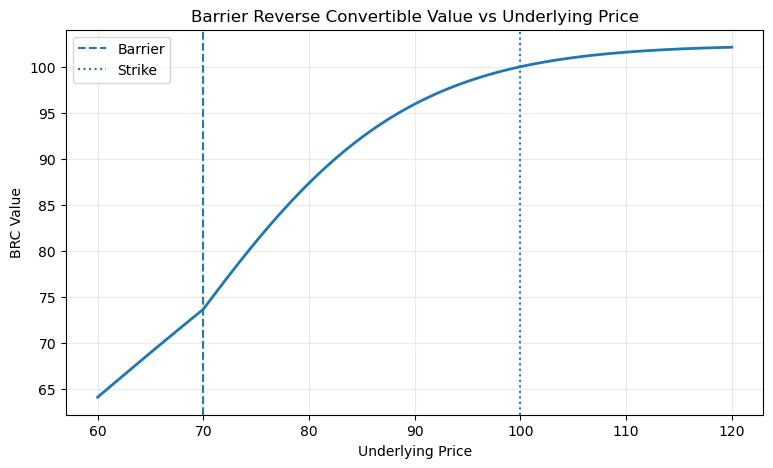

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    spot_grid,
    brc_values,
    linewidth=2
)

plt.axvline(
    barrier,
    linestyle="--",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike"
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Value")
plt.title("Barrier Reverse Convertible Value vs Underlying Price")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

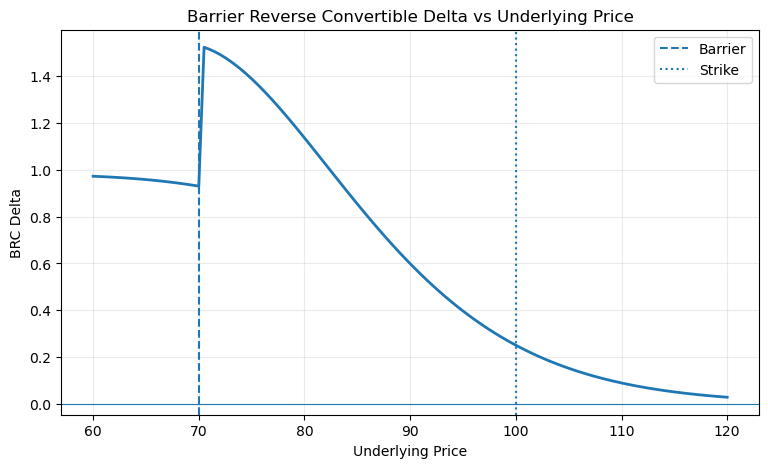

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    spot_grid,
    brc_deltas,
    linewidth=2
)

plt.axvline(
    barrier,
    linestyle="--",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike"
)

plt.axhline(
    0.0,
    linewidth=0.8
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Delta")
plt.title("Barrier Reverse Convertible Delta vs Underlying Price")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

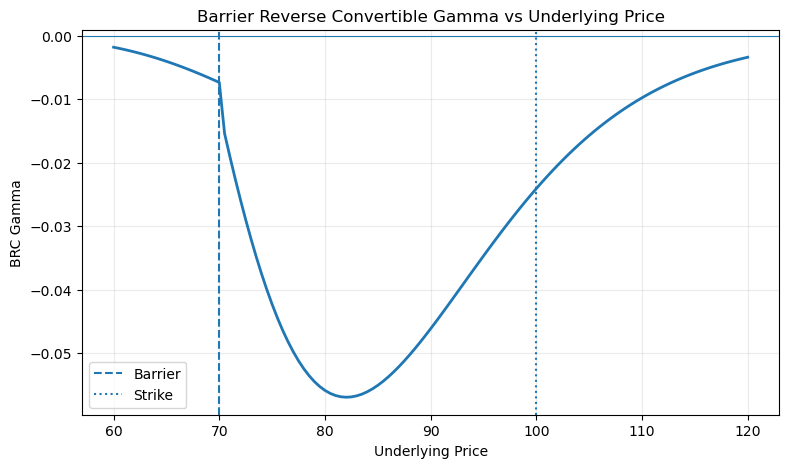

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    spot_grid,
    brc_gammas,
    linewidth=2
)

plt.axvline(
    barrier,
    linestyle="--",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike"
)

plt.axhline(
    0.0,
    linewidth=0.8
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Gamma")
plt.title("Barrier Reverse Convertible Gamma vs Underlying Price")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Pre-Knock-In vs Post-Knock-In Risk

A Barrier Reverse Convertible is path-dependent.

Two notes with the same current underlying price can have different values and risk exposures depending on whether the downside barrier has already been breached.

Before the knock-in, the embedded option remains a down-and-in put:

$$
V_{\text{option}} = P_{DI}
$$

Once the barrier has been breached, the knock-in condition is permanently satisfied and the embedded option becomes economically equivalent to a vanilla put:

$$
V_{\text{option}} = P_{\text{Vanilla}}
$$

Therefore:

$$
V_{\text{BRC}}^{\text{pre-KI}}
\neq
V_{\text{BRC}}^{\text{post-KI}}
$$

even when both notes have the same current spot price.

This change in risk profile around the barrier is particularly important for the issuing desk's dynamic hedge.

In [23]:
comparison_spots = np.linspace(
    barrier + 0.5,
    120.0,
    100
)

pre_ki_values = []
post_ki_values = []

pre_ki_deltas = []
post_ki_deltas = []

for spot_level in comparison_spots:

    # Pre-knock-in state
    pre_value = brc_price(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=False
    )

    pre_delta, _ = brc_delta_gamma(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=False
    )

    # Post-knock-in state
    post_value = brc_price(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=True
    )

    post_delta, _ = brc_delta_gamma(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=True
    )

    pre_ki_values.append(pre_value)
    post_ki_values.append(post_value)

    pre_ki_deltas.append(pre_delta)
    post_ki_deltas.append(post_delta)

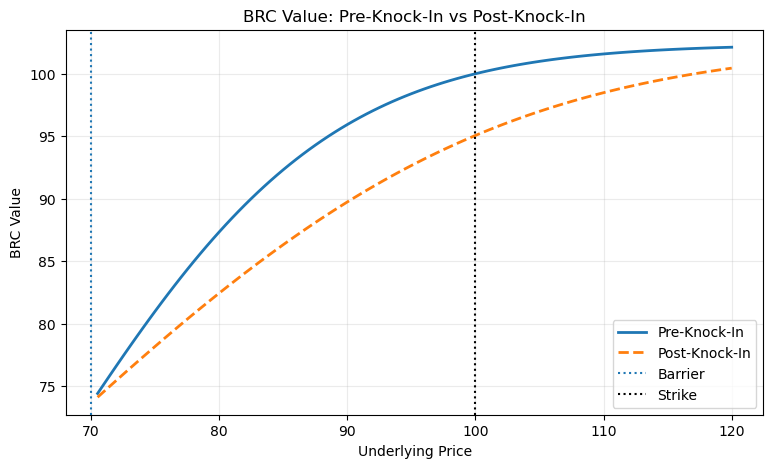

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    comparison_spots,
    pre_ki_values,
    linewidth=2,
    label="Pre-Knock-In"
)

plt.plot(
    comparison_spots,
    post_ki_values,
    linewidth=2,
    linestyle="--",
    label="Post-Knock-In"
)

plt.axvline(
    barrier,
    linestyle=":",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike",color="black"
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Value")
plt.title("BRC Value: Pre-Knock-In vs Post-Knock-In")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

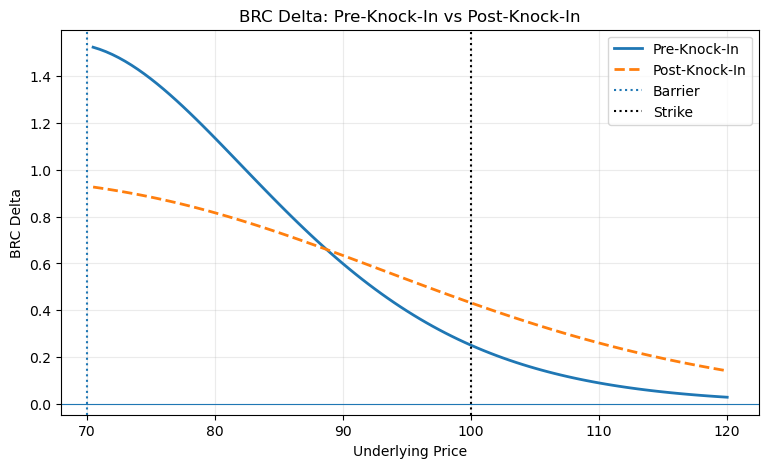

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    comparison_spots,
    pre_ki_deltas,
    linewidth=2,
    label="Pre-Knock-In"
)

plt.plot(
    comparison_spots,
    post_ki_deltas,
    linewidth=2,
    linestyle="--",
    label="Post-Knock-In"
)

plt.axvline(
    barrier,
    linestyle=":",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike",color="black"
)

plt.axhline(
    0.0,
    linewidth=0.8
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Delta")
plt.title("BRC Delta: Pre-Knock-In vs Post-Knock-In")

plt.legend()
plt.grid(alpha=0.25)
plt.savefig(
    "../figures/pre_post_knockin_delta.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [26]:
vega_spots = np.linspace(
    barrier + 0.5,
    120.0,
    100
)

pre_ki_vegas = []
post_ki_vegas = []

for spot_level in vega_spots:

    pre_vega = brc_vega(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=False
    )

    post_vega = brc_vega(
        spot=spot_level,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_dates=coupon_dates,
        barrier_hit=True
    )

    pre_ki_vegas.append(pre_vega)
    post_ki_vegas.append(post_vega)

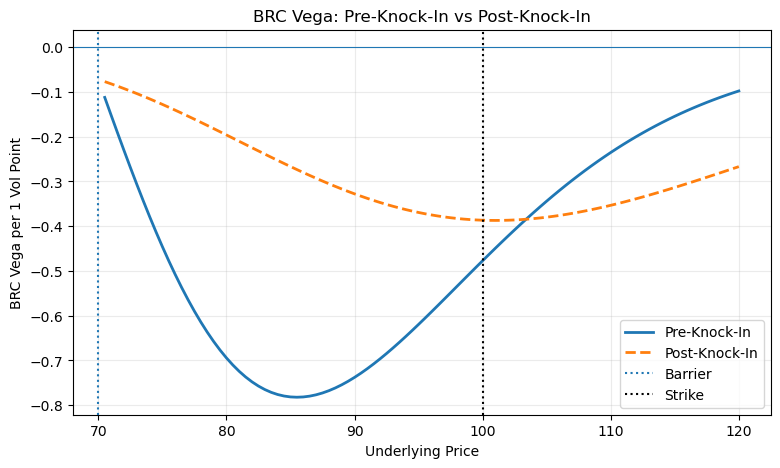

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    vega_spots,
    pre_ki_vegas,
    linewidth=2,
    label="Pre-Knock-In"
)

plt.plot(
    vega_spots,
    post_ki_vegas,
    linewidth=2,
    linestyle="--",
    label="Post-Knock-In"
)

plt.axvline(
    barrier,
    linestyle=":",
    label="Barrier"
)

plt.axvline(
    strike,
    linestyle=":",
    label="Strike",color="black"
)

plt.axhline(
    0.0,
    linewidth=0.8
)

plt.xlabel("Underlying Price")
plt.ylabel("BRC Vega per 1 Vol Point")
plt.title("BRC Vega: Pre-Knock-In vs Post-Knock-In")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [28]:
volatility_grid = np.linspace(
    0.10,
    0.40,
    31
)

fair_coupons_by_vol = []

for vol in volatility_grid:

    coupon = fair_coupon_rate(
        spot=initial_spot,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=vol,
        notional=notional,
        issue_price=issue_price,
        coupon_dates=coupon_dates
    )

    fair_coupons_by_vol.append(coupon)

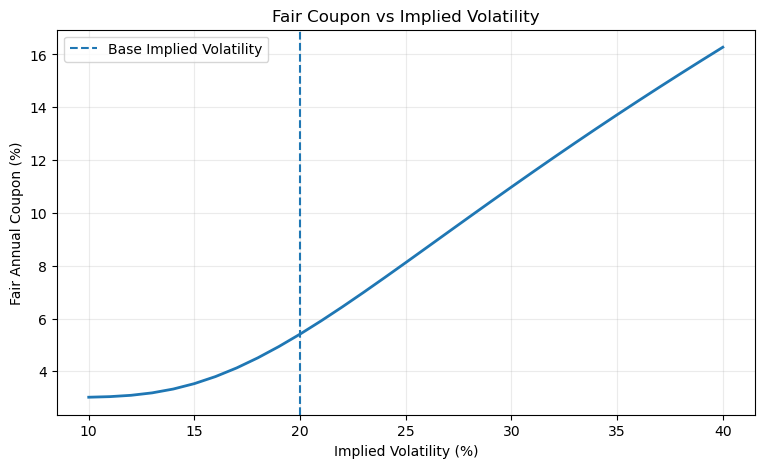

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    volatility_grid * 100,
    np.array(fair_coupons_by_vol) * 100,
    linewidth=2
)

plt.axvline(
    implied_volatility * 100,
    linestyle="--",
    label="Base Implied Volatility"
)

plt.xlabel("Implied Volatility (%)")
plt.ylabel("Fair Annual Coupon (%)")
plt.title("Fair Coupon vs Implied Volatility")

plt.legend()
plt.grid(alpha=0.25)
plt.savefig(
    "../figures/fair_coupon_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
barrier_grid = np.linspace(
    0.50,
    0.90,
    41
) * initial_spot

fair_coupons_by_barrier = []

for barrier_level in barrier_grid:

    coupon = fair_coupon_rate(
        spot=initial_spot,
        strike=strike,
        barrier=barrier_level,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        issue_price=issue_price,
        coupon_dates=coupon_dates
    )

    fair_coupons_by_barrier.append(coupon)

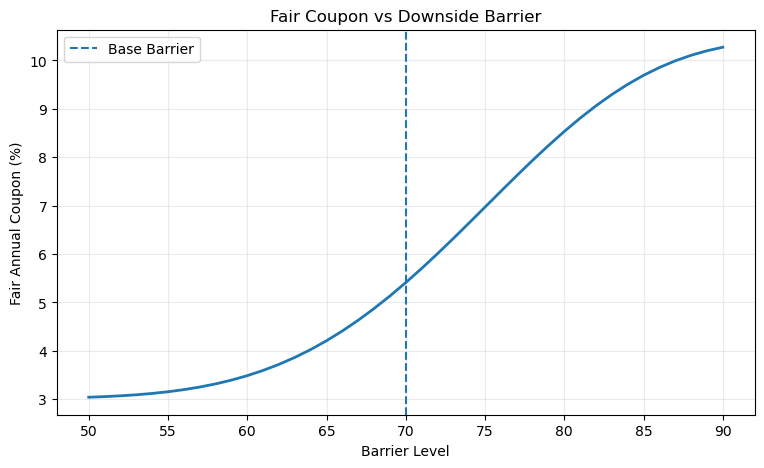

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    barrier_grid,
    np.array(fair_coupons_by_barrier) * 100,
    linewidth=2
)

plt.axvline(
    barrier,
    linestyle="--",
    label="Base Barrier"
)

plt.xlabel("Barrier Level")
plt.ylabel("Fair Annual Coupon (%)")
plt.title("Fair Coupon vs Downside Barrier")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 6. Dynamic Delta Hedging

The issuing desk is short the Barrier Reverse Convertible sold to the investor.

Therefore:

$$
V_{\text{desk}}=-V_{\text{BRC}}
$$

and:

$$
\Delta_{\text{desk}}=-\Delta_{\text{BRC}}
$$

To neutralize the first-order equity exposure, the desk holds:

$$
n_t=\Delta_{\text{BRC},t}
$$

shares of the underlying.

As the underlying price, time to maturity and barrier state evolve, the BRC delta changes. The stock hedge must therefore be rebalanced dynamically.

The hedging simulation tracks:

- the underlying price;
- the knock-in state;
- the BRC mark-to-market;
- the BRC delta;
- the stock hedge;
- the financing cash account;
- the resulting hedging P&L.

In [32]:
def brc_price_at_time(
    current_spot,
    valuation_time,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    annual_coupon_rate,
    coupon_frequency,
    coupon_dates,
    barrier_hit
):
    """
    Mark-to-market a BRC at an intermediate valuation time.

    Only coupons that have not yet been paid are included.
    """

    remaining_maturity = maturity - valuation_time

    if remaining_maturity <= 0:
        return 0.0

    # Principal component
    principal_pv = (
        notional
        * np.exp(-rate * remaining_maturity)
    )

    # Keep only coupons strictly after the valuation time
    remaining_coupon_dates = coupon_dates[
        coupon_dates > valuation_time + 1e-12
    ]

    coupon_payment = (
        notional
        * annual_coupon_rate
        / coupon_frequency
    )

    remaining_coupon_times = (
        remaining_coupon_dates - valuation_time
    )

    coupons_pv = coupon_payment * np.sum(
        np.exp(-rate * remaining_coupon_times)
    )

    # Once the barrier has been hit, the embedded option
    # is economically a vanilla put.
    if barrier_hit:

        embedded_put = black_scholes_put(
            current_spot,
            strike,
            remaining_maturity,
            rate,
            dividend_yield,
            volatility
        )

    else:

        embedded_put = down_and_in_put(
            current_spot,
            strike,
            barrier,
            remaining_maturity,
            rate,
            dividend_yield,
            volatility
        )

    option_units = notional / strike

    return (
        principal_pv
        + coupons_pv
        - option_units * embedded_put
    )

In [33]:
def brc_delta_at_time(
    current_spot,
    valuation_time,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    annual_coupon_rate,
    coupon_frequency,
    coupon_dates,
    barrier_hit,
    spot_bump=0.01
):
    """
    Compute the BRC delta at an intermediate valuation time
    using central finite differences.
    """

    price_up = brc_price_at_time(
        current_spot + spot_bump,
        valuation_time,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        notional,
        annual_coupon_rate,
        coupon_frequency,
        coupon_dates,
        barrier_hit
    )

    price_down = brc_price_at_time(
        current_spot - spot_bump,
        valuation_time,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        notional,
        annual_coupon_rate,
        coupon_frequency,
        coupon_dates,
        barrier_hit
    )

    return (
        price_up - price_down
    ) / (2.0 * spot_bump)

In [34]:
initial_price_time_aware = brc_price_at_time(
    current_spot=initial_spot,
    valuation_time=0.0,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    barrier_hit=False
)

initial_delta_time_aware = brc_delta_at_time(
    current_spot=initial_spot,
    valuation_time=0.0,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    barrier_hit=False
)

print(f"Original price:   {calibrated_brc_price:.6f}")
print(f"Time-aware price: {initial_price_time_aware:.6f}")

print()
print(f"Original delta:   {initial_delta:.6f}")
print(f"Time-aware delta: {initial_delta_time_aware:.6f}")

assert np.isclose(
    initial_price_time_aware,
    calibrated_brc_price,
    atol=1e-10
)

assert np.isclose(
    initial_delta_time_aware,
    initial_delta,
    atol=1e-6
)

print("\nTime-aware pricing checks passed.")

Original price:   100.000000
Time-aware price: 100.000000

Original delta:   0.250758
Time-aware delta: 0.250758

Time-aware pricing checks passed.


In [35]:
def simulate_stock_path(
    initial_spot,
    maturity,
    drift,
    dividend_yield,
    realized_volatility,
    n_steps,
    rng
):
    """
    Simulate one stock-price path using exact GBM discretization.
    """

    dt = maturity / n_steps

    shocks = rng.standard_normal(n_steps)

    log_returns = (
        (
            drift
            - dividend_yield
            - 0.5 * realized_volatility**2
        ) * dt
        + realized_volatility
        * np.sqrt(dt)
        * shocks
    )

    path = np.empty(n_steps + 1)

    path[0] = initial_spot

    path[1:] = (
        initial_spot
        * np.exp(np.cumsum(log_returns))
    )

    return path

In [36]:
n_trading_days = 252

realized_volatility = implied_volatility

# The drift assumption is not the main driver of the hedging experiment.
# We initially set it equal to the risk-free rate.
simulation_drift = risk_free_rate

stock_path = simulate_stock_path(
    initial_spot=initial_spot,
    maturity=maturity,
    drift=simulation_drift,
    dividend_yield=dividend_yield,
    realized_volatility=realized_volatility,
    n_steps=n_trading_days,
    rng=rng
)

time_grid = np.linspace(
    0.0,
    maturity,
    n_trading_days + 1
)

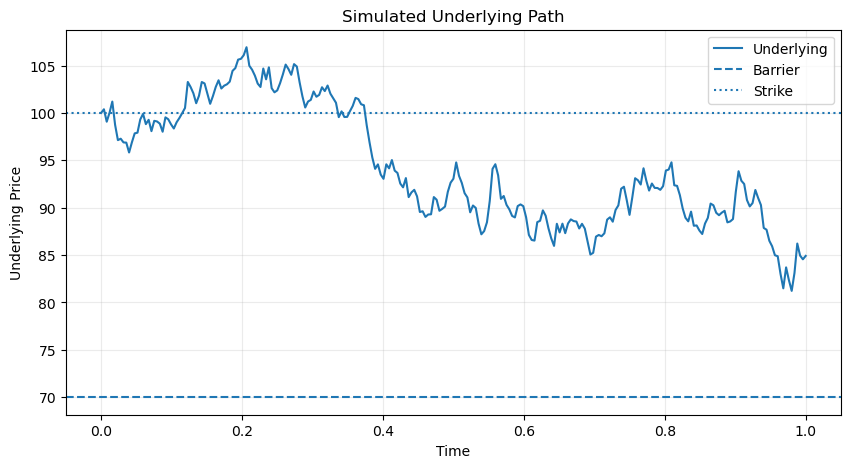

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_grid,
    stock_path,
    linewidth=1.5,
    label="Underlying"
)

plt.axhline(
    barrier,
    linestyle="--",
    label="Barrier"
)

plt.axhline(
    strike,
    linestyle=":",
    label="Strike"
)

plt.xlabel("Time")
plt.ylabel("Underlying Price")
plt.title("Simulated Underlying Path")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Continuous Barrier Monitoring with a Brownian Bridge

The underlying is simulated at discrete daily intervals, while the BRC barrier is monitored continuously.

Checking only the simulated daily prices would therefore underestimate the probability of a barrier breach, since the underlying may cross the barrier between two consecutive observations.

Under geometric Brownian motion, conditional on two consecutive stock prices $S_t$ and $S_{t+\Delta t}$ that are both above the barrier, the probability of crossing a lower barrier $B$ between the two observations is:

$$
p_{\text{hit}}
=
\exp\left(
-\frac{
2\ln(S_t/B)\ln(S_{t+\Delta t}/B)
}{
\sigma^2 \Delta t
}
\right)
$$

If either endpoint is already at or below the barrier, the barrier event has occurred with certainty.

A Bernoulli draw based on this conditional crossing probability is used to reconstruct the continuously monitored knock-in state along each simulated path.

In [38]:
def barrier_crossing_probability(
    spot_start,
    spot_end,
    barrier,
    volatility,
    dt
):
    """
    Conditional probability that a GBM path crosses a lower barrier
    between two consecutive observations.

    Brownian-bridge correction for continuous barrier monitoring.
    """

    # If either endpoint is at or below the barrier,
    # the barrier has certainly been breached.
    if spot_start <= barrier or spot_end <= barrier:
        return 1.0

    log_distance_start = np.log(spot_start / barrier)
    log_distance_end = np.log(spot_end / barrier)

    crossing_probability = np.exp(
        -2.0
        * log_distance_start
        * log_distance_end
        / (volatility**2 * dt)
    )

    return crossing_probability

In [39]:
dt = maturity / n_trading_days

# Far from the barrier
prob_far = barrier_crossing_probability(
    spot_start=100.0,
    spot_end=98.0,
    barrier=barrier,
    volatility=realized_volatility,
    dt=dt
)

# Close to the barrier
prob_close = barrier_crossing_probability(
    spot_start=71.0,
    spot_end=72.0,
    barrier=barrier,
    volatility=realized_volatility,
    dt=dt
)

# Endpoint already below the barrier
prob_breached = barrier_crossing_probability(
    spot_start=71.0,
    spot_end=69.0,
    barrier=barrier,
    volatility=realized_volatility,
    dt=dt
)

print(f"Far from barrier:   {prob_far:.6f}")
print(f"Close to barrier:   {prob_close:.6f}")
print(f"Barrier breached:   {prob_breached:.6f}")

assert 0.0 <= prob_far <= 1.0
assert 0.0 <= prob_close <= 1.0
assert prob_close > prob_far
assert prob_breached == 1.0

Far from barrier:   0.000000
Close to barrier:   0.006507
Barrier breached:   1.000000


In [40]:
def build_barrier_state(
    stock_path,
    barrier,
    volatility,
    maturity,
    rng
):
    """
    Reconstruct the continuously monitored barrier state
    along a discretely simulated GBM path using Brownian bridges.
    """

    n_steps = len(stock_path) - 1
    dt = maturity / n_steps

    barrier_hit = np.zeros(
        len(stock_path),
        dtype=bool
    )

    for i in range(1, len(stock_path)):

        # Once knocked in, the barrier state remains active.
        if barrier_hit[i - 1]:
            barrier_hit[i] = True
            continue

        crossing_probability = barrier_crossing_probability(
            spot_start=stock_path[i - 1],
            spot_end=stock_path[i],
            barrier=barrier,
            volatility=volatility,
            dt=dt
        )

        # Draw the latent intra-period barrier event.
        barrier_hit[i] = (
            rng.random() < crossing_probability
        )

    return barrier_hit

In [41]:
barrier_state = build_barrier_state(
    stock_path=stock_path,
    barrier=barrier,
    volatility=realized_volatility,
    maturity=maturity,
    rng=rng
)

if np.any(barrier_state):

    first_hit_index = np.argmax(barrier_state)

    first_hit_time = time_grid[first_hit_index]

    print("Barrier event: Yes")
    print(f"Detected at approximately t = {first_hit_time:.4f}")

else:

    print("Barrier event: No")

Barrier event: No


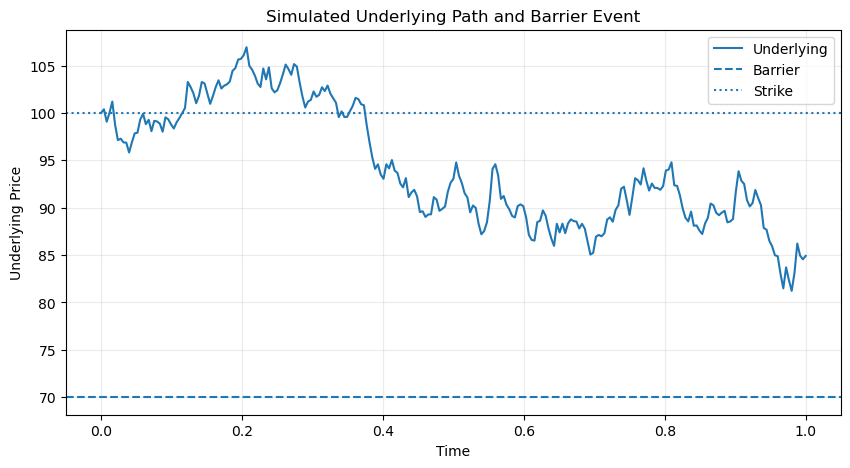

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_grid,
    stock_path,
    linewidth=1.5,
    label="Underlying"
)

plt.axhline(
    barrier,
    linestyle="--",
    label="Barrier"
)

plt.axhline(
    strike,
    linestyle=":",
    label="Strike"
)

if np.any(barrier_state):

    first_hit_index = np.argmax(barrier_state)

    plt.axvline(
        time_grid[first_hit_index],
        linestyle="--",
        label="Knock-In"
    )

plt.xlabel("Time")
plt.ylabel("Underlying Price")
plt.title("Simulated Underlying Path and Barrier Event")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Self-Financing Hedge

The issuing desk receives the note issue price and dynamically hedges its equity exposure by trading the underlying stock.

At each rebalancing date, the hedge position is set to:

$$
n_t = \Delta_{\text{BRC},t}
$$

The hedging portfolio consists of:

$$
\Pi_t = n_t S_t + C_t
$$

where $C_t$ is the financing cash account.

The strategy is self-financing: purchases and sales of the underlying are funded through the cash account.

Between two rebalancing dates:

- the cash account accrues at the risk-free rate;
- the stock position earns dividends;
- contractual BRC coupons are paid by the issuer.

At maturity, the stock hedge is liquidated and the final BRC redemption is paid. The remaining cash represents the desk's hedging P&L.

In [43]:
def coupon_cashflow_between(
    time_start,
    time_end,
    coupon_dates,
    annual_coupon_rate,
    notional,
    coupon_frequency
):
    """
    Return the contractual coupon cash flow paid between
    two consecutive hedge dates.
    """

    coupon_payment = (
        notional
        * annual_coupon_rate
        / coupon_frequency
    )

    coupons_due = np.sum(
        (coupon_dates > time_start + 1e-12)
        & (coupon_dates <= time_end + 1e-12)
    )

    return coupons_due * coupon_payment

In [44]:
def simulate_delta_hedge(
    stock_path,
    barrier_state,
    time_grid,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    implied_volatility,
    notional,
    annual_coupon_rate,
    coupon_frequency,
    coupon_dates,
    issue_price
):
    """
    Simulate the issuing desk's daily self-financing delta hedge
    along one underlying path.
    """

    n_steps = len(stock_path) - 1

    # Containers used to store the trading history
    brc_values = np.zeros(n_steps + 1)
    brc_deltas = np.zeros(n_steps + 1)
    hedge_shares = np.zeros(n_steps + 1)
    cash_account = np.zeros(n_steps + 1)

    # Initial BRC mark-to-market
    brc_values[0] = brc_price_at_time(
        current_spot=stock_path[0],
        valuation_time=0.0,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=annual_coupon_rate,
        coupon_frequency=coupon_frequency,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_state[0]
    )

    # Initial delta hedge
    brc_deltas[0] = brc_delta_at_time(
        current_spot=stock_path[0],
        valuation_time=0.0,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=annual_coupon_rate,
        coupon_frequency=coupon_frequency,
        coupon_dates=coupon_dates,
        barrier_hit=barrier_state[0]
    )

    hedge_shares[0] = brc_deltas[0]

    # The desk receives the issue price and uses part of it
    # to purchase the initial stock hedge.
    cash_account[0] = (
        issue_price
        - hedge_shares[0] * stock_path[0]
    )

    for i in range(1, n_steps + 1):

        dt = time_grid[i] - time_grid[i - 1]

        previous_shares = hedge_shares[i - 1]

        # Financing account accrues at the risk-free rate.
        cash = (
            cash_account[i - 1]
            * np.exp(rate * dt)
        )

        # Continuous dividend yield earned on the stock hedge
        # over the interval.
        dividend_cashflow = (
            previous_shares
            * dividend_yield
            * stock_path[i - 1]
            * dt
        )

        cash += dividend_cashflow

        # Contractual coupon paid by the issuing desk.
        coupon_cashflow = coupon_cashflow_between(
            time_start=time_grid[i - 1],
            time_end=time_grid[i],
            coupon_dates=coupon_dates,
            annual_coupon_rate=annual_coupon_rate,
            notional=notional,
            coupon_frequency=coupon_frequency
        )

        cash -= coupon_cashflow

        # At maturity, no further hedge is required.
        if i == n_steps:
            brc_values[i] = 0.0
            brc_deltas[i] = 0.0
            hedge_shares[i] = 0.0

            # Liquidate the existing stock hedge.
            cash += previous_shares * stock_path[i]

            cash_account[i] = cash

            continue

        # Mark the BRC using the current barrier state.
        brc_values[i] = brc_price_at_time(
            current_spot=stock_path[i],
            valuation_time=time_grid[i],
            strike=strike,
            barrier=barrier,
            maturity=maturity,
            rate=rate,
            dividend_yield=dividend_yield,
            volatility=implied_volatility,
            notional=notional,
            annual_coupon_rate=annual_coupon_rate,
            coupon_frequency=coupon_frequency,
            coupon_dates=coupon_dates,
            barrier_hit=barrier_state[i]
        )

        # Recalculate the required stock hedge.
        brc_deltas[i] = brc_delta_at_time(
            current_spot=stock_path[i],
            valuation_time=time_grid[i],
            strike=strike,
            barrier=barrier,
            maturity=maturity,
            rate=rate,
            dividend_yield=dividend_yield,
            volatility=implied_volatility,
            notional=notional,
            annual_coupon_rate=annual_coupon_rate,
            coupon_frequency=coupon_frequency,
            coupon_dates=coupon_dates,
            barrier_hit=barrier_state[i]
        )

        hedge_shares[i] = brc_deltas[i]

        # Buy or sell the change in the stock hedge.
        shares_traded = (
            hedge_shares[i]
            - previous_shares
        )

        cash -= (
            shares_traded
            * stock_path[i]
        )

        cash_account[i] = cash

    # Final principal redemption owed to the investor.
    final_redemption = brc_redemption(
        final_spot=stock_path[-1],
        barrier_hit=barrier_state[-1],
        notional=notional,
        strike=strike
    )

    cash_account[-1] -= final_redemption

    hedging_pnl = cash_account[-1]

    results = pd.DataFrame({
        "Time": time_grid,
        "Spot": stock_path,
        "Barrier Hit": barrier_state,
        "BRC Value": brc_values,
        "BRC Delta": brc_deltas,
        "Hedge Shares": hedge_shares,
        "Cash Account": cash_account
    })

    return results, hedging_pnl

In [45]:
hedge_results, hedging_pnl = simulate_delta_hedge(
    stock_path=stock_path,
    barrier_state=barrier_state,
    time_grid=time_grid,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price
)

print(f"Final stock price: {stock_path[-1]:.2f}")
print(f"Barrier hit:       {barrier_state[-1]}")
print(f"Hedging P&L:       {hedging_pnl:.4f}")

Final stock price: 84.91
Barrier hit:       False
Hedging P&L:       -0.8755


In [46]:
hedge_results.head(10)

,Time,Spot,Barrier Hit,BRC Value,BRC Delta,Hedge Shares,Cash Account
0,0.000000,100.000000,False,100.000000,0.250758,0.250758,74.924187
1,0.003968,100.380662,False,100.123348,0.240712,0.240712,75.943567
2,0.007937,99.070065,False,99.818089,0.271907,0.271907,72.863983
3,0.011905,100.007226,False,100.091818,0.247483,0.247483,75.317404
4,0.015873,101.195345,False,100.398204,0.219256,0.219256,78.184811
5,0.019841,98.734294,False,99.819336,0.277549,0.277549,72.440286
6,0.023810,97.123828,False,99.369500,0.322032,0.322032,68.130784
7,0.027778,97.276525,False,99.451251,0.316400,0.316400,68.689180
8,0.031746,96.885874,False,99.358722,0.327107,0.327107,67.662492
9,0.035714,96.861524,False,99.384158,0.326772,0.326772,67.705513


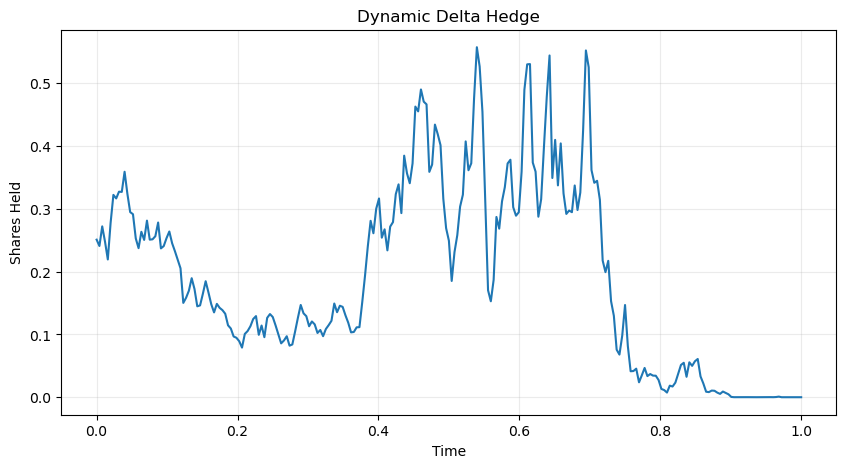

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    hedge_results["Time"],
    hedge_results["Hedge Shares"],
    linewidth=1.5
)

if np.any(barrier_state):

    first_hit_index = np.argmax(barrier_state)

    plt.axvline(
        time_grid[first_hit_index],
        linestyle="--",
        label="Knock-In"
    )

plt.xlabel("Time")
plt.ylabel("Shares Held")
plt.title("Dynamic Delta Hedge")

if np.any(barrier_state):
    plt.legend()

plt.grid(alpha=0.25)
plt.show()

## 7. Monte Carlo Hedging P&L

A single hedging path provides limited information about the performance of the strategy.

To assess the residual risk of dynamic delta hedging, the trading strategy is repeated across many simulated market paths.

For each path:

1. the underlying is simulated under geometric Brownian motion;
2. continuous barrier monitoring is approximated using Brownian bridges;
3. the knock-in state is tracked through time;
4. the desk dynamically rebalances its delta hedge;
5. coupons, dividends and financing cash flows are accounted for;
6. the final note redemption is settled.

The remaining terminal cash balance represents the hedging P&L.

Even when realized volatility equals the implied volatility used for pricing, discrete rebalancing generates a non-zero distribution of hedging errors.

In [48]:
def run_hedging_monte_carlo(
    n_paths,
    initial_spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    implied_volatility,
    realized_volatility,
    simulation_drift,
    notional,
    annual_coupon_rate,
    coupon_frequency,
    coupon_dates,
    issue_price,
    n_steps,
    seed
):
    """
    Simulate the distribution of terminal hedging P&L
    for the issuing desk.
    """

    local_rng = np.random.default_rng(seed)

    time_grid_mc = np.linspace(
        0.0,
        maturity,
        n_steps + 1
    )

    pnl = np.zeros(n_paths)
    final_spots = np.zeros(n_paths)
    barrier_hits = np.zeros(n_paths, dtype=bool)

    for path_index in range(n_paths):

        stock_path_mc = simulate_stock_path(
            initial_spot=initial_spot,
            maturity=maturity,
            drift=simulation_drift,
            dividend_yield=dividend_yield,
            realized_volatility=realized_volatility,
            n_steps=n_steps,
            rng=local_rng
        )

        barrier_state_mc = build_barrier_state(
            stock_path=stock_path_mc,
            barrier=barrier,
            volatility=realized_volatility,
            maturity=maturity,
            rng=local_rng
        )

        _, path_pnl = simulate_delta_hedge(
            stock_path=stock_path_mc,
            barrier_state=barrier_state_mc,
            time_grid=time_grid_mc,
            strike=strike,
            barrier=barrier,
            maturity=maturity,
            rate=rate,
            dividend_yield=dividend_yield,
            implied_volatility=implied_volatility,
            notional=notional,
            annual_coupon_rate=annual_coupon_rate,
            coupon_frequency=coupon_frequency,
            coupon_dates=coupon_dates,
            issue_price=issue_price
        )

        pnl[path_index] = path_pnl
        final_spots[path_index] = stock_path_mc[-1]
        barrier_hits[path_index] = barrier_state_mc[-1]

    results = pd.DataFrame({
        "Hedging P&L": pnl,
        "Final Spot": final_spots,
        "Barrier Hit": barrier_hits
    })

    return results

In [49]:
# Small sample used to validate the Monte Carlo engine
# before running the optimized large-scale simulation.
n_mc_paths = 50

mc_results = run_hedging_monte_carlo(
    n_paths=n_mc_paths,
    initial_spot=initial_spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    realized_volatility=implied_volatility,
    simulation_drift=risk_free_rate,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price,
    n_steps=n_trading_days,
    seed=123
)

mc_results.head()

,Hedging P&L,Final Spot,Barrier Hit
0,-0.142696,124.410680,False
1,0.169249,106.179092,False
2,0.016470,97.908692,False
3,0.068610,102.362043,False
4,-0.177453,124.840348,False


In [50]:
pnl_summary = pd.Series({
    "Mean P&L": mc_results["Hedging P&L"].mean(),
    "P&L Std": mc_results["Hedging P&L"].std(),
    "5th Percentile": mc_results["Hedging P&L"].quantile(0.05),
    "Median": mc_results["Hedging P&L"].median(),
    "95th Percentile": mc_results["Hedging P&L"].quantile(0.95),
    "Barrier Hit Rate": mc_results["Barrier Hit"].mean()
})

pnl_summary

Mean P&L           -0.209987
P&L Std             1.458979
5th Percentile     -0.554727
Median             -0.034977
95th Percentile     0.453599
Barrier Hit Rate    0.020000
dtype: float64

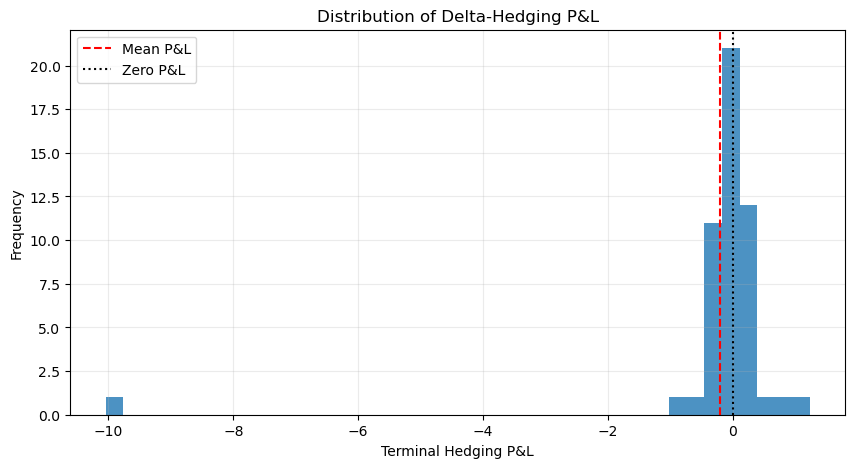

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    mc_results["Hedging P&L"],
    bins=40,
    alpha=0.8
)

plt.axvline(
    mc_results["Hedging P&L"].mean(),
    linestyle="--",
    label="Mean P&L",color="red"
)

plt.axvline(
    0.0,
    linestyle=":",
    label="Zero P&L",color="black"
)

plt.xlabel("Terminal Hedging P&L")
plt.ylabel("Frequency")
plt.title("Distribution of Delta-Hedging P&L")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [52]:
pnl_by_barrier = mc_results.groupby(
    "Barrier Hit"
)["Hedging P&L"].agg(
    ["count", "mean", "std", "min", "max"]
)

pnl_by_barrier

,count,mean,std,min,max
Barrier Hit,,,,,
False,49,-0.213050,1.473936,-10.047246,1.234939
True,1,-0.059903,NaN,-0.059903,-0.059903


### Scalable Hedging Simulation

The previous implementation was designed to provide a transparent path-by-path trading ledger.

While useful for understanding the mechanics of the hedge, repeatedly repricing the BRC through nested Python loops becomes computationally expensive when thousands of paths are simulated.

For the large-scale hedging experiments, the simulation is therefore separated into two layers:

- the detailed single-path engine remains available for trade-level analysis;
- a more efficient Monte Carlo engine is used for statistical hedging analysis.

This allows the project to preserve transparency while making large-scale risk simulations computationally practical.

In [53]:
def black_scholes_put_vectorized(
    spot,
    strike,
    maturity,
    rate,
    dividend_yield,
    volatility
):
    """
    Vectorized Black-Scholes put price.
    """

    spot = np.asarray(spot, dtype=float)
    maturity = np.asarray(maturity, dtype=float)

    safe_maturity = np.maximum(maturity, 1e-12)

    sqrt_t = np.sqrt(safe_maturity)

    d1 = (
        np.log(spot / strike)
        + (
            rate
            - dividend_yield
            + 0.5 * volatility**2
        ) * safe_maturity
    ) / (
        volatility * sqrt_t
    )

    d2 = (
        d1
        - volatility * sqrt_t
    )

    put_price = (
        strike
        * np.exp(-rate * safe_maturity)
        * norm.cdf(-d2)
        - spot
        * np.exp(-dividend_yield * safe_maturity)
        * norm.cdf(-d1)
    )

    return put_price

In [54]:
def down_and_out_put_vectorized(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility
):
    """
    Vectorized continuously monitored down-and-out put.
    Assumes spot > barrier and barrier < strike.
    """

    spot = np.asarray(spot, dtype=float)

    safe_maturity = max(maturity, 1e-12)

    log_spot = np.log(spot)
    log_barrier = np.log(barrier)
    log_strike = np.log(strike)

    drift = (
        rate
        - dividend_yield
        - 0.5 * volatility**2
    )

    variance = (
        volatility**2
        * safe_maturity
    )

    std = np.sqrt(variance)

    mean_direct = (
        log_spot
        + drift * safe_maturity
    )

    mean_reflected = (
        2.0 * log_barrier
        - log_spot
        + drift * safe_maturity
    )

    reflection_coefficient = np.exp(
        2.0
        * drift
        * (log_barrier - log_spot)
        / volatility**2
    )

    def truncated_moment(
        lower,
        upper,
        mean,
        order
    ):

        z_upper = (
            upper
            - mean
            - order * variance
        ) / std

        z_lower = (
            lower
            - mean
            - order * variance
        ) / std

        return np.exp(
            order * mean
            + 0.5 * order**2 * variance
        ) * (
            norm.cdf(z_upper)
            - norm.cdf(z_lower)
        )

    direct_probability = truncated_moment(
        log_barrier,
        log_strike,
        mean_direct,
        0
    )

    direct_stock = truncated_moment(
        log_barrier,
        log_strike,
        mean_direct,
        1
    )

    reflected_probability = truncated_moment(
        log_barrier,
        log_strike,
        mean_reflected,
        0
    )

    reflected_stock = truncated_moment(
        log_barrier,
        log_strike,
        mean_reflected,
        1
    )

    direct_payoff = (
        strike * direct_probability
        - direct_stock
    )

    reflected_payoff = (
        reflection_coefficient
        * (
            strike * reflected_probability
            - reflected_stock
        )
    )

    return np.maximum(
        np.exp(-rate * safe_maturity)
        * (
            direct_payoff
            - reflected_payoff
        ),
        0.0
    )

In [55]:
def down_and_in_put_vectorized(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    barrier_hit
):
    """
    Vectorized down-and-in put price.

    If the barrier has already been hit, or if the current spot
    is at or below the barrier, the option is equivalent to a
    vanilla put.
    """

    spot = np.asarray(spot, dtype=float)
    barrier_hit = np.asarray(barrier_hit, dtype=bool)

    vanilla_put = black_scholes_put_vectorized(
        spot=spot,
        strike=strike,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=volatility
    )

    effective_knock_in = barrier_hit | (spot <= barrier)

    down_in_put = vanilla_put.copy()

    pre_knock_in = ~effective_knock_in

    if np.any(pre_knock_in):

        down_out_put = down_and_out_put_vectorized(
            spot=spot[pre_knock_in],
            strike=strike,
            barrier=barrier,
            maturity=maturity,
            rate=rate,
            dividend_yield=dividend_yield,
            volatility=volatility
        )

        down_in_put[pre_knock_in] = (
            vanilla_put[pre_knock_in] - down_out_put
        )

    return down_in_put

In [56]:
def brc_delta_vectorized(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    notional,
    barrier_hit,
    spot_bump=0.01
):
    """
    Vectorized BRC delta using finite differences
    on the embedded put component.
    """

    spot = np.asarray(
        spot,
        dtype=float
    )

    price_up = down_and_in_put_vectorized(
        spot + spot_bump,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        barrier_hit
    )

    price_down = down_and_in_put_vectorized(
        spot - spot_bump,
        strike,
        barrier,
        maturity,
        rate,
        dividend_yield,
        volatility,
        barrier_hit
    )

    embedded_put_delta = (
        price_up
        - price_down
    ) / (
        2.0 * spot_bump
    )

    return (
        -(notional / strike)
        * embedded_put_delta
    )

In [57]:
vectorized_initial_delta = brc_delta_vectorized(
    spot=np.array([initial_spot]),
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility,
    notional=notional,
    barrier_hit=np.array([False])
)[0]

print(
    f"Original delta:   "
    f"{initial_delta_time_aware:.6f}"
)

print(
    f"Vectorized delta: "
    f"{vectorized_initial_delta:.6f}"
)

print(
    f"Difference:       "
    f"{vectorized_initial_delta - initial_delta_time_aware:.10f}"
)

assert np.isclose(
    vectorized_initial_delta,
    initial_delta_time_aware,
    atol=1e-6
)

print("\nVectorized delta check passed.")

Original delta:   0.250758
Vectorized delta: 0.250758
Difference:       0.0000000000

Vectorized delta check passed.


In [58]:
def simulate_stock_paths_vectorized(
    n_paths,
    initial_spot,
    maturity,
    drift,
    dividend_yield,
    realized_volatility,
    n_steps,
    rng
):
    """
    Simulate multiple GBM stock paths simultaneously.
    """

    dt = maturity / n_steps

    shocks = rng.standard_normal(
        size=(n_paths, n_steps)
    )

    log_returns = (
        (
            drift
            - dividend_yield
            - 0.5 * realized_volatility**2
        ) * dt
        + realized_volatility
        * np.sqrt(dt)
        * shocks
    )

    cumulative_log_returns = np.cumsum(
        log_returns,
        axis=1
    )

    stock_paths = np.empty(
        (n_paths, n_steps + 1)
    )

    stock_paths[:, 0] = initial_spot

    stock_paths[:, 1:] = (
        initial_spot
        * np.exp(cumulative_log_returns)
    )

    return stock_paths

In [59]:
def build_barrier_states_vectorized(
    stock_paths,
    barrier,
    volatility,
    maturity,
    rng
):
    """
    Reconstruct continuously monitored barrier states
    for multiple simulated paths using Brownian bridges.
    """

    n_paths, n_columns = stock_paths.shape
    n_steps = n_columns - 1

    dt = maturity / n_steps

    spot_start = stock_paths[:, :-1]
    spot_end = stock_paths[:, 1:]

    endpoint_hit = (
        (spot_start <= barrier)
        | (spot_end <= barrier)
    )

    crossing_probability = np.ones_like(
        spot_start
    )

    both_above = ~endpoint_hit

    crossing_probability[both_above] = np.exp(
        -2.0
        * np.log(
            spot_start[both_above] / barrier
        )
        * np.log(
            spot_end[both_above] / barrier
        )
        / (
            volatility**2 * dt
        )
    )

    uniforms = rng.random(
        size=(n_paths, n_steps)
    )

    interval_hit = (
        uniforms < crossing_probability
    )

    # Once the barrier is hit, the state remains True.
    barrier_states = np.zeros(
        (n_paths, n_steps + 1),
        dtype=bool
    )

    barrier_states[:, 1:] = (
        np.maximum.accumulate(
            interval_hit,
            axis=1
        )
    )

    return barrier_states

In [60]:
test_rng = np.random.default_rng(123)

test_paths = simulate_stock_paths_vectorized(
    n_paths=1000,
    initial_spot=initial_spot,
    maturity=maturity,
    drift=risk_free_rate,
    dividend_yield=dividend_yield,
    realized_volatility=implied_volatility,
    n_steps=252,
    rng=test_rng
)

test_barrier_states = build_barrier_states_vectorized(
    stock_paths=test_paths,
    barrier=barrier,
    volatility=implied_volatility,
    maturity=maturity,
    rng=test_rng
)

print("Stock paths shape:")
print(test_paths.shape)

print()

print("Barrier states shape:")
print(test_barrier_states.shape)

print()

print(
    f"Barrier hit rate: "
    f"{test_barrier_states[:, -1].mean():.2%}"
)

Stock paths shape:
(1000, 253)

Barrier states shape:
(1000, 253)

Barrier hit rate: 8.20%


### Hedge Rebalancing Frequency

Barrier monitoring and hedge rebalancing are two distinct mechanisms.

The BRC barrier remains continuously monitored regardless of how frequently the desk adjusts its stock hedge.

The underlying is therefore simulated on a daily grid and the continuous barrier event is reconstructed using Brownian bridges.

The desk can then rebalance its hedge at different frequencies while keeping the contractual barrier monitoring unchanged.

The following strategies will be compared:

- Daily hedging: every trading day
- Weekly hedging: every 5 trading days
- Monthly hedging: every 21 trading days

This isolates the impact of hedge frequency on residual hedging risk.

In [61]:
def run_vectorized_hedge(
    stock_paths,
    barrier_states,
    maturity,
    strike,
    barrier,
    rate,
    dividend_yield,
    implied_volatility,
    notional,
    annual_coupon_rate,
    coupon_frequency,
    coupon_dates,
    issue_price,
    rebalance_every=1
):
    """
    Run a vectorized self-financing delta hedge across
    multiple simulated stock paths.

    rebalance_every:
        1  = daily
        5  = approximately weekly
        21 = approximately monthly
    """

    n_paths, n_columns = stock_paths.shape
    n_steps = n_columns - 1

    dt = maturity / n_steps

    time_grid = np.linspace(
        0.0,
        maturity,
        n_steps + 1
    )

    # Initial delta is identical across all paths.
    initial_delta = brc_delta_vectorized(
        spot=stock_paths[:, 0],
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        notional=notional,
        barrier_hit=barrier_states[:, 0]
    )

    hedge_shares = initial_delta.copy()

    # The desk receives the issue price and purchases
    # the initial stock hedge.
    cash = (
        issue_price
        - hedge_shares * stock_paths[:, 0]
    )

    coupon_payment = (
        notional
        * annual_coupon_rate
        / coupon_frequency
    )

    for i in range(1, n_steps + 1):

        previous_spot = stock_paths[:, i - 1]
        current_spot = stock_paths[:, i]

        # Financing of the cash account.
        cash *= np.exp(rate * dt)

        # Dividend income earned on the stock position.
        cash += (
            hedge_shares
            * dividend_yield
            * previous_spot
            * dt
        )

        # Pay contractual coupons falling inside this interval.
        coupons_due = np.sum(
            (coupon_dates > time_grid[i - 1] + 1e-12)
            & (coupon_dates <= time_grid[i] + 1e-12)
        )

        if coupons_due > 0:
            cash -= coupons_due * coupon_payment

        # No new hedge is required at maturity.
        if i == n_steps:
            break

        # Rebalance only at the selected trading frequency.
        if i % rebalance_every == 0:

            remaining_maturity = (
                maturity - time_grid[i]
            )

            new_delta = brc_delta_vectorized(
                spot=current_spot,
                strike=strike,
                barrier=barrier,
                maturity=remaining_maturity,
                rate=rate,
                dividend_yield=dividend_yield,
                volatility=implied_volatility,
                notional=notional,
                barrier_hit=barrier_states[:, i]
            )

            shares_traded = (
                new_delta - hedge_shares
            )

            # Purchases reduce cash and sales increase cash.
            cash -= (
                shares_traded
                * current_spot
            )

            hedge_shares = new_delta

    # Liquidate the remaining stock hedge at maturity.
    cash += (
        hedge_shares
        * stock_paths[:, -1]
    )

    final_spot = stock_paths[:, -1]
    final_barrier_hit = barrier_states[:, -1]

    # Principal redemption owed to the investor.
    downside_loss = (
        (notional / strike)
        * np.maximum(
            strike - final_spot,
            0.0
        )
        * final_barrier_hit
    )

    final_redemption = (
        notional - downside_loss
    )

    cash -= final_redemption

    return cash

In [62]:
single_path_matrix = stock_path.reshape(1, -1)

single_barrier_matrix = barrier_state.reshape(1, -1)

vectorized_single_pnl = run_vectorized_hedge(
    stock_paths=single_path_matrix,
    barrier_states=single_barrier_matrix,
    maturity=maturity,
    strike=strike,
    barrier=barrier,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price,
    rebalance_every=1
)[0]

print(
    f"Detailed engine P&L:   "
    f"{hedging_pnl:.6f}"
)

print(
    f"Vectorized engine P&L: "
    f"{vectorized_single_pnl:.6f}"
)

print(
    f"Difference:            "
    f"{vectorized_single_pnl - hedging_pnl:.10f}"
)

Detailed engine P&L:   -0.875467
Vectorized engine P&L: -0.875467
Difference:            0.0000000000


In [63]:
n_final_paths = 5000

final_rng = np.random.default_rng(2026)

mc_stock_paths = simulate_stock_paths_vectorized(
    n_paths=n_final_paths,
    initial_spot=initial_spot,
    maturity=maturity,
    drift=risk_free_rate,
    dividend_yield=dividend_yield,
    realized_volatility=implied_volatility,
    n_steps=252,
    rng=final_rng
)

mc_barrier_states = build_barrier_states_vectorized(
    stock_paths=mc_stock_paths,
    barrier=barrier,
    volatility=implied_volatility,
    maturity=maturity,
    rng=final_rng
)

daily_pnl = run_vectorized_hedge(
    stock_paths=mc_stock_paths,
    barrier_states=mc_barrier_states,
    maturity=maturity,
    strike=strike,
    barrier=barrier,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price,
    rebalance_every=1
)

In [64]:
daily_pnl_summary = pd.Series({
    "Number of Paths": len(daily_pnl),
    "Mean P&L": np.mean(daily_pnl),
    "P&L Std": np.std(
        daily_pnl,
        ddof=1
    ),
    "5th Percentile": np.quantile(
        daily_pnl,
        0.05
    ),
    "Median": np.median(
        daily_pnl
    ),
    "95th Percentile": np.quantile(
        daily_pnl,
        0.95
    ),
    "Barrier Hit Rate": np.mean(
        mc_barrier_states[:, -1]
    )
})

daily_pnl_summary

Number of Paths     5000.000000
Mean P&L               0.010910
P&L Std                1.348408
5th Percentile        -1.239853
Median                -0.010094
95th Percentile        1.286852
Barrier Hit Rate       0.084200
dtype: float64

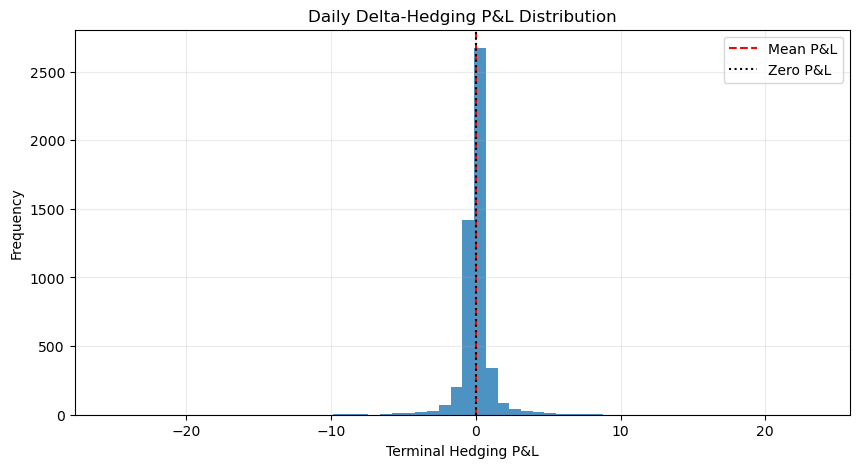

In [65]:
plt.figure(figsize=(10, 5))

plt.hist(
    daily_pnl,
    bins=60,
    alpha=0.8
)

plt.axvline(
    np.mean(daily_pnl),
    linestyle="--",
    label="Mean P&L",color="red"
)

plt.axvline(
    0.0,
    linestyle=":",
    label="Zero P&L",color="black"
)

plt.xlabel("Terminal Hedging P&L")
plt.ylabel("Frequency")
plt.title(
    "Daily Delta-Hedging P&L Distribution"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [66]:
weekly_pnl = run_vectorized_hedge(
    stock_paths=mc_stock_paths,
    barrier_states=mc_barrier_states,
    maturity=maturity,
    strike=strike,
    barrier=barrier,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price,
    rebalance_every=5
)

monthly_pnl = run_vectorized_hedge(
    stock_paths=mc_stock_paths,
    barrier_states=mc_barrier_states,
    maturity=maturity,
    strike=strike,
    barrier=barrier,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    implied_volatility=implied_volatility,
    notional=notional,
    annual_coupon_rate=fair_coupon,
    coupon_frequency=coupon_frequency,
    coupon_dates=coupon_dates,
    issue_price=issue_price,
    rebalance_every=21
)

In [67]:
hedge_frequency_results = pd.DataFrame({
    "Daily": [
        np.mean(daily_pnl),
        np.std(daily_pnl, ddof=1),
        np.quantile(daily_pnl, 0.05),
        np.quantile(daily_pnl, 0.95)
    ],
    "Weekly": [
        np.mean(weekly_pnl),
        np.std(weekly_pnl, ddof=1),
        np.quantile(weekly_pnl, 0.05),
        np.quantile(weekly_pnl, 0.95)
    ],
    "Monthly": [
        np.mean(monthly_pnl),
        np.std(monthly_pnl, ddof=1),
        np.quantile(monthly_pnl, 0.05),
        np.quantile(monthly_pnl, 0.95)
    ]
}, index=[
    "Mean P&L",
    "P&L Std",
    "5th Percentile",
    "95th Percentile"
])

hedge_frequency_results

,Daily,Weekly,Monthly
Mean P&L,0.010910,0.046538,-0.005362
P&L Std,1.348408,2.524572,4.025799
5th Percentile,-1.239853,-2.789159,-5.152589
95th Percentile,1.286852,3.102391,6.189821


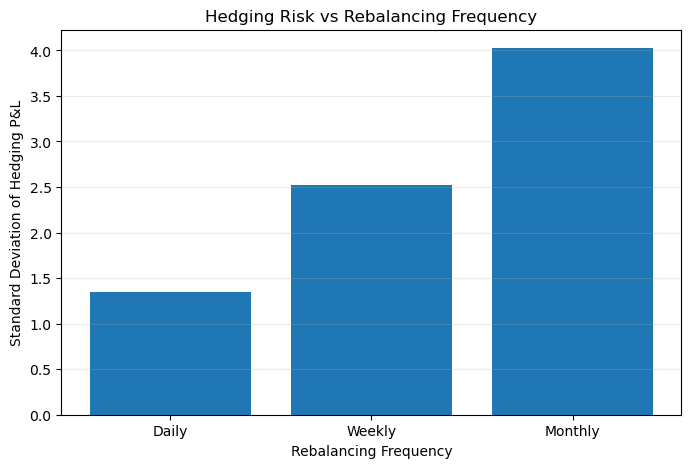

In [68]:
hedge_frequencies = [
    "Daily",
    "Weekly",
    "Monthly"
]

pnl_std = [
    np.std(daily_pnl, ddof=1),
    np.std(weekly_pnl, ddof=1),
    np.std(monthly_pnl, ddof=1)
]

plt.figure(figsize=(8, 5))

plt.bar(
    hedge_frequencies,
    pnl_std
)

plt.xlabel("Rebalancing Frequency")
plt.ylabel("Standard Deviation of Hedging P&L")
plt.title(
    "Hedging Risk vs Rebalancing Frequency"
)

plt.grid(
    axis="y",
    alpha=0.25
)
plt.savefig(
    "../figures/hedging_pnl_std_frequency.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 8. Implied vs Realized Volatility

The BRC is initially priced and hedged using an implied volatility of 20%.

Once the trade has been issued, the contractual coupon remains fixed. The actual underlying path, however, may realize a different level of volatility.

To study this effect, the desk keeps the pricing and hedging volatility constant at:

$$
\sigma_{\text{imp}} = 20\%
$$

while market paths are simulated under different realized volatility scenarios:

$$
\sigma_{\text{real}} \in
\{15\%, 20\%, 25\%, 30\%\}.
$$

For each scenario, the desk applies the same daily delta-hedging strategy.

This experiment illustrates how residual hedging P&L depends on the difference between the volatility embedded in the initial pricing of the structured product and the volatility subsequently realized by the underlying.

In [69]:
realized_volatility_scenarios = [
    0.15,
    0.20,
    0.25,
    0.30
]

n_vol_paths = 5000

volatility_pnl_results = {}
volatility_barrier_rates = {}

In [70]:
for realized_vol in realized_volatility_scenarios:

    scenario_rng = np.random.default_rng(2026)

    scenario_paths = simulate_stock_paths_vectorized(
        n_paths=n_vol_paths,
        initial_spot=initial_spot,
        maturity=maturity,
        drift=risk_free_rate,
        dividend_yield=dividend_yield,
        realized_volatility=realized_vol,
        n_steps=252,
        rng=scenario_rng
    )

    scenario_barrier_states = build_barrier_states_vectorized(
        stock_paths=scenario_paths,
        barrier=barrier,
        volatility=realized_vol,
        maturity=maturity,
        rng=scenario_rng
    )

    scenario_pnl = run_vectorized_hedge(
        stock_paths=scenario_paths,
        barrier_states=scenario_barrier_states,
        maturity=maturity,
        strike=strike,
        barrier=barrier,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        implied_volatility=implied_volatility,
        notional=notional,
        annual_coupon_rate=fair_coupon,
        coupon_frequency=coupon_frequency,
        coupon_dates=coupon_dates,
        issue_price=issue_price,
        rebalance_every=1
    )

    volatility_pnl_results[realized_vol] = scenario_pnl

    volatility_barrier_rates[realized_vol] = (
        scenario_barrier_states[:, -1].mean()
    )

In [71]:
volatility_results = []

for realized_vol in realized_volatility_scenarios:

    pnl = volatility_pnl_results[
        realized_vol
    ]

    volatility_results.append({
        "Realized Volatility": realized_vol,
        "Mean P&L": np.mean(pnl),
        "P&L Std": np.std(
            pnl,
            ddof=1
        ),
        "5th Percentile": np.quantile(
            pnl,
            0.05
        ),
        "Median": np.median(pnl),
        "95th Percentile": np.quantile(
            pnl,
            0.95
        ),
        "Barrier Hit Rate": volatility_barrier_rates[
            realized_vol
        ]
    })

volatility_results_df = pd.DataFrame(
    volatility_results
)

volatility_results_df[
    "Realized Volatility"
] *= 100

volatility_results_df

,Realized Volatility,Mean P&L,P&L Std,5th Percentile,Median,95th Percentile,Barrier Hit Rate
0,15.0,-1.914963,2.121915,-5.781976,-1.237349,-0.360823,0.0142
1,20.0,0.010910,1.348408,-1.239853,-0.010094,1.286852,0.0842
2,25.0,2.763321,3.089558,0.274783,1.762452,8.263991,0.1702
3,30.0,5.706319,5.555529,0.645272,4.075743,15.941185,0.2648


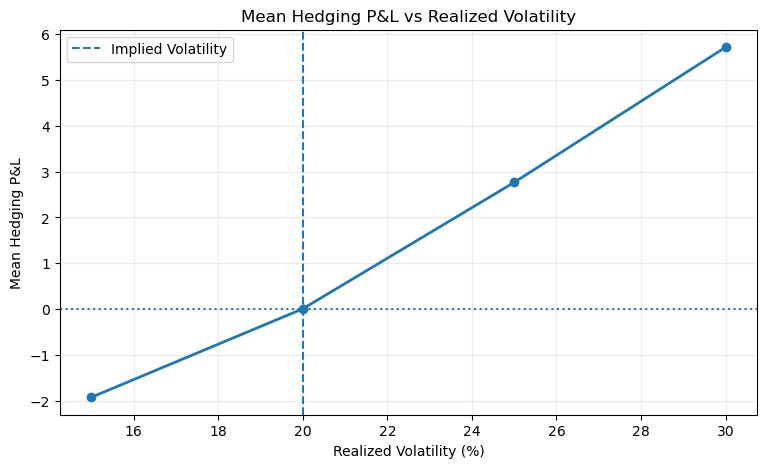

In [72]:
mean_pnl_by_vol = [
    np.mean(
        volatility_pnl_results[vol]
    )
    for vol in realized_volatility_scenarios
]

plt.figure(figsize=(9, 5))

plt.plot(
    np.array(
        realized_volatility_scenarios
    ) * 100,
    mean_pnl_by_vol,
    marker="o",
    linewidth=2
)

plt.axvline(
    implied_volatility * 100,
    linestyle="--",
    label="Implied Volatility"
)

plt.axhline(
    0.0,
    linestyle=":"
)

plt.xlabel("Realized Volatility (%)")
plt.ylabel("Mean Hedging P&L")
plt.title(
    "Mean Hedging P&L vs Realized Volatility"
)

plt.legend()
plt.grid(alpha=0.25)
plt.savefig(
    "../figures/hedging_pnl_realized_volatility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

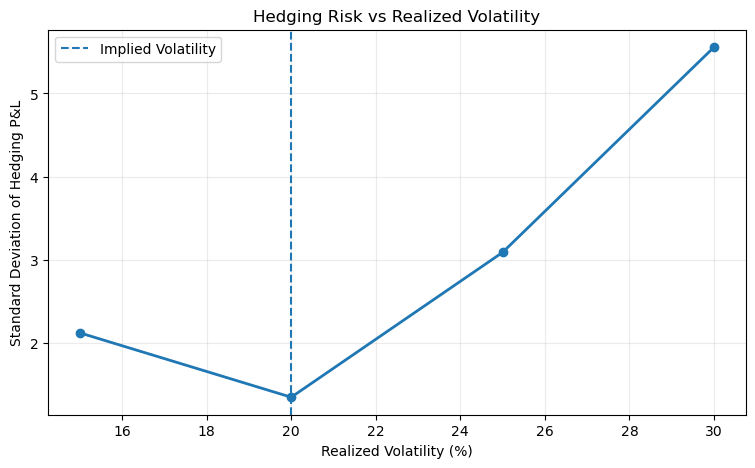

In [73]:
pnl_std_by_vol = [
    np.std(
        volatility_pnl_results[vol],
        ddof=1
    )
    for vol in realized_volatility_scenarios
]

plt.figure(figsize=(9, 5))

plt.plot(
    np.array(
        realized_volatility_scenarios
    ) * 100,
    pnl_std_by_vol,
    marker="o",
    linewidth=2
)

plt.axvline(
    implied_volatility * 100,
    linestyle="--",
    label="Implied Volatility"
)

plt.xlabel("Realized Volatility (%)")
plt.ylabel("Standard Deviation of Hedging P&L")
plt.title(
    "Hedging Risk vs Realized Volatility"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()

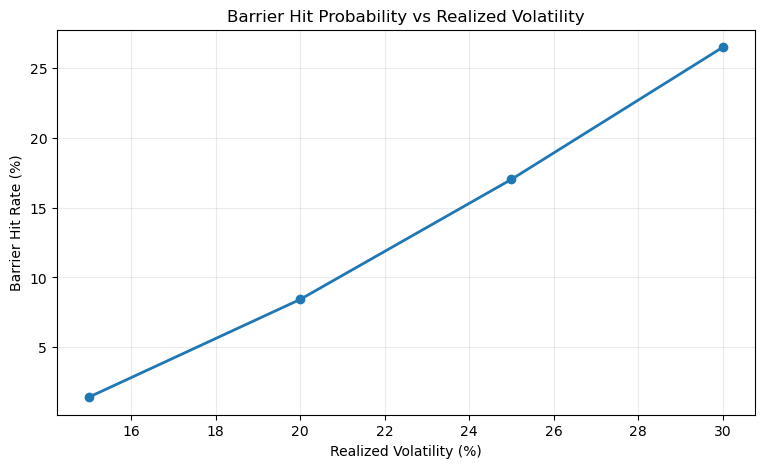

In [74]:
barrier_hit_rates = [
    volatility_barrier_rates[vol]
    for vol in realized_volatility_scenarios
]

plt.figure(figsize=(9, 5))

plt.plot(
    np.array(
        realized_volatility_scenarios
    ) * 100,
    np.array(
        barrier_hit_rates
    ) * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Realized Volatility (%)")
plt.ylabel("Barrier Hit Rate (%)")
plt.title(
    "Barrier Hit Probability vs Realized Volatility"
)

plt.grid(alpha=0.25)
plt.show()

### Trading Interpretation

The simulation highlights three distinct sources of risk for the issuing desk.

**Discrete hedging risk.**  
Delta hedging removes the local first-order equity exposure, but the hedge is only rebalanced at discrete intervals. Changes in delta between two rebalancing dates therefore generate residual P&L.

**Volatility risk.**  
The note is priced using implied volatility, while the underlying subsequently realizes its own volatility. A difference between implied and realized volatility affects the performance of the dynamic hedge.

**Barrier risk.**  
The knock-in feature introduces additional path dependency. As the underlying approaches the downside barrier, the risk profile of the embedded option can change rapidly. Once the barrier is breached, the embedded down-and-in put becomes economically equivalent to a vanilla put.

The issuing desk therefore manages more than a simple directional equity exposure. The trade combines delta, gamma, volatility and barrier-state risk.

## 9. Independent Barrier Pricing Validation

The analytical down-and-in put pricer is a central component of the BRC valuation and hedging framework.

In-out parity alone does not provide an independent validation because the down-and-in put was constructed as:

$$
P_{DI} = P_{\text{Vanilla}} - P_{DO}.
$$

The analytical barrier price is therefore benchmarked against an independent Monte Carlo estimator.

Under GBM, the terminal stock price is simulated exactly:

$$
S_T
=
S_0
\exp\left[
\left(r-q-\frac{1}{2}\sigma^2\right)T
+
\sigma\sqrt{T}Z
\right].
$$

Conditional on $S_0>B$ and $S_T>B$, the probability that the continuously monitored path crossed the lower barrier during the life of the option is:

$$
p_{\text{hit}}
=
\exp\left(
-\frac{
2\ln(S_0/B)\ln(S_T/B)
}{
\sigma^2T
}
\right).
$$

If $S_T \leq B$, the barrier has necessarily been breached.

The Monte Carlo down-and-in put payoff is then:

$$
(K-S_T)^+
\mathbf{1}_{\{\tau_B\leq T\}}.
$$

In [75]:
def monte_carlo_down_and_in_put(
    spot,
    strike,
    barrier,
    maturity,
    rate,
    dividend_yield,
    volatility,
    n_paths,
    seed
):
    """
    Independently price a continuously monitored down-and-in put
    using exact terminal GBM simulation and a Brownian-bridge
    barrier-crossing probability.
    """

    rng = np.random.default_rng(seed)

    # Simulate terminal stock prices exactly under
    # the risk-neutral GBM dynamics.
    z = rng.standard_normal(n_paths)

    terminal_spot = (
        spot
        * np.exp(
            (
                rate
                - dividend_yield
                - 0.5 * volatility**2
            ) * maturity
            + volatility
            * np.sqrt(maturity)
            * z
        )
    )

    # Paths ending below the barrier must have crossed it.
    barrier_hit = (
        terminal_spot <= barrier
    )

    # For paths ending above the barrier, use the exact
    # conditional Brownian-bridge crossing probability.
    above_barrier = ~barrier_hit

    crossing_probability = np.exp(
        -2.0
        * np.log(spot / barrier)
        * np.log(
            terminal_spot[above_barrier]
            / barrier
        )
        / (
            volatility**2
            * maturity
        )
    )

    uniforms = rng.random(
        np.sum(above_barrier)
    )

    barrier_hit[above_barrier] = (
        uniforms < crossing_probability
    )

    payoff = (
        np.maximum(
            strike - terminal_spot,
            0.0
        )
        * barrier_hit
    )

    discount_factor = np.exp(
        -rate * maturity
    )

    discounted_payoff = (
        discount_factor * payoff
    )

    mc_price = np.mean(
        discounted_payoff
    )

    standard_error = (
        np.std(
            discounted_payoff,
            ddof=1
        )
        / np.sqrt(n_paths)
    )

    return mc_price, standard_error

In [76]:
n_validation_paths = 500_000

mc_di_price, mc_di_standard_error = (
    monte_carlo_down_and_in_put(
        spot=initial_spot,
        strike=strike,
        barrier=barrier,
        maturity=maturity,
        rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=implied_volatility,
        n_paths=n_validation_paths,
        seed=42
    )
)

analytical_di_price = down_and_in_put(
    spot=initial_spot,
    strike=strike,
    barrier=barrier,
    maturity=maturity,
    rate=risk_free_rate,
    dividend_yield=dividend_yield,
    volatility=implied_volatility
)

pricing_difference = (
    mc_di_price
    - analytical_di_price
)

z_score = (
    pricing_difference
    / mc_di_standard_error
)

print(
    f"Analytical DI Put:     "
    f"{analytical_di_price:.6f}"
)

print(
    f"Monte Carlo DI Put:    "
    f"{mc_di_price:.6f}"
)

print(
    f"MC Standard Error:     "
    f"{mc_di_standard_error:.6f}"
)

print(
    f"Pricing Difference:    "
    f"{pricing_difference:.6f}"
)

print(
    f"Difference / MC SE:    "
    f"{z_score:.2f}"
)

Analytical DI Put:     2.354874
Monte Carlo DI Put:    2.367680
MC Standard Error:     0.011591
Pricing Difference:    0.012805
Difference / MC SE:    1.10


In [77]:
confidence_lower = (
    mc_di_price
    - 1.96 * mc_di_standard_error
)

confidence_upper = (
    mc_di_price
    + 1.96 * mc_di_standard_error
)

print(
    f"95% Monte Carlo CI: "
    f"[{confidence_lower:.6f}, "
    f"{confidence_upper:.6f}]"
)

print(
    f"Analytical Price:   "
    f"{analytical_di_price:.6f}"
)

if (
    confidence_lower
    <= analytical_di_price
    <= confidence_upper
):
    print(
        "\nAnalytical price lies inside "
        "the 95% Monte Carlo confidence interval."
    )

else:
    print(
        "\nAnalytical price lies outside "
        "the 95% Monte Carlo confidence interval."
    )

95% Monte Carlo CI: [2.344961, 2.390398]
Analytical Price:   2.354874

Analytical price lies inside the 95% Monte Carlo confidence interval.


In [78]:
relative_error = (
    abs(
        mc_di_price
        - analytical_di_price
    )
    / analytical_di_price
)

print(
    f"Relative Pricing Error: "
    f"{relative_error:.4%}"
)

Relative Pricing Error: 0.5438%


In [79]:
validation_table = pd.DataFrame({
    "Metric": [
        "Analytical DI Put",
        "Monte Carlo DI Put",
        "Monte Carlo Standard Error",
        "Absolute Difference",
        "Difference / Standard Error",
        "Relative Difference"
    ],
    "Value": [
        analytical_di_price,
        mc_di_price,
        mc_di_standard_error,
        pricing_difference,
        z_score,
        abs(pricing_difference) / analytical_di_price
    ]
})

validation_table

,Metric,Value
0,Analytical DI Put,2.354874
1,Monte Carlo DI Put,2.367680
2,Monte Carlo Standard Error,0.011591
3,Absolute Difference,0.012805
4,Difference / Standard Error,1.104746
5,Relative Difference,0.005438


### Validation Result

The analytical down-and-in put price is consistent with the independent Monte Carlo benchmark.

The difference between the two estimates is approximately 1.1 Monte Carlo standard errors, indicating that the observed pricing difference is compatible with simulation uncertainty.

This provides an independent numerical validation of the continuous-barrier pricing engine used throughout the project.

## 10. Key Trading Insights

The Barrier Reverse Convertible can be interpreted from the investor perspective as:

$$
\text{BRC}
=
\text{Bond}
+
\text{Coupons}
-
\text{Down-and-In Put}.
$$

From the issuing desk's perspective, the position is reversed. The desk is therefore exposed to the embedded downside optionality and must dynamically manage the resulting equity and volatility risks.

The numerical analysis leads to several trading insights.

### 1. The enhanced coupon compensates the investor for selling downside optionality

The coupon is not an independent source of return. It is partly financed by the value of the embedded down-and-in put sold by the investor.

Higher implied volatility increases the value of this downside optionality and therefore supports a higher model-implied fair coupon.

Similarly, raising the downside barrier makes the knock-in event more likely and increases the value of the embedded option, allowing a higher coupon to be offered.

### 2. Barrier activation materially changes the risk profile

Before knock-in, the embedded option is a down-and-in put.

After knock-in, it becomes economically equivalent to a vanilla put:

$$
P_{DI}
\rightarrow
P_{\text{Vanilla}}.
$$

Two BRCs with the same current underlying price can therefore have different values and hedge ratios depending on their historical barrier state.

### 3. Delta hedging does not eliminate the desk's risk

The issuing desk can neutralize the local first-order equity exposure by holding:

$$
n_t=\Delta_{\text{BRC},t}
$$

shares of the underlying.

However, the hedge must be continuously adjusted as spot, time and the barrier state evolve.

With discrete rebalancing, movements between hedge dates generate residual hedging P&L.

### 4. Hedge frequency affects residual P&L risk

More frequent delta rebalancing generally reduces the amount of unhedged underlying movement between hedge adjustments.

The Monte Carlo experiment therefore compares daily, weekly and monthly rebalancing while keeping the contractual barrier monitoring unchanged.

This distinction is important: hedge frequency is a trading decision, whereas barrier monitoring is a contractual feature of the note.

### 5. Implied and realized volatility play different roles

Implied volatility determines the initial model value, fair coupon and hedge ratios used by the desk.

Realized volatility determines the actual path followed by the underlying after issuance.

A divergence between the volatility embedded in the trade and the volatility subsequently realized by the market affects the performance and dispersion of the dynamic hedge.

### 6. Barrier products introduce path-dependent hedging risk

The desk must track not only the current underlying price but also whether the barrier has previously been breached.

Continuous barrier monitoring was incorporated through Brownian-bridge crossing probabilities, allowing barrier events between daily simulated observations to be captured.

The trade therefore combines delta, gamma, volatility and barrier-state risk rather than representing a simple directional equity position.

## 11. Model Limitations

The framework is intentionally simplified to isolate the main structuring and hedging mechanics of the Barrier Reverse Convertible.

The main assumptions are:

- Black-Scholes dynamics with constant volatility;
- constant risk-free rate and dividend yield;
- no volatility skew or term structure;
- no stochastic interest rates;
- no transaction costs or bid-ask spreads;
- no stock borrow or funding spread;
- no issuer credit risk;
- continuous theoretical barrier monitoring approximated through Brownian bridges;
- discrete delta hedging;
- no volatility or gamma hedging instruments.

In practice, an issuing desk would incorporate market-implied volatility surfaces, funding and credit considerations, transaction costs, liquidity constraints and additional risk-management instruments.

The model should therefore be interpreted as a controlled framework for studying the core pricing and dynamic hedging mechanics rather than a full production structured-products pricing system.

In [80]:
final_trade_summary = pd.DataFrame({
    "Metric": [
        "Issue Price",
        "Fair Annual Coupon",
        "Strike",
        "Downside Barrier",
        "Maturity",
        "Implied Volatility",
        "Analytical DI Put",
        "Monte Carlo DI Put",
        "MC Pricing Difference"
    ],
    "Value": [
        f"{issue_price:.2f}",
        f"{fair_coupon:.2%}",
        f"{strike_pct:.0%}",
        f"{barrier_pct:.0%}",
        f"{maturity:.1f} year",
        f"{implied_volatility:.0%}",
        f"{analytical_di_price:.4f}",
        f"{mc_di_price:.4f}",
        f"{pricing_difference:.4f}"
    ]
})

final_trade_summary

,Metric,Value
0,Issue Price,100.00
1,Fair Annual Coupon,5.41%
2,Strike,100%
3,Downside Barrier,70%
4,Maturity,1.0 year
5,Implied Volatility,20%
6,Analytical DI Put,2.3549
7,Monte Carlo DI Put,2.3677
8,MC Pricing Difference,0.0128


## Conclusion

This project implemented the full lifecycle of a Barrier Reverse Convertible from structuring and pricing to dynamic risk management.

The note was decomposed into its funding and embedded option components, allowing the fair coupon and risk sensitivities to be derived consistently. Continuous barrier monitoring was incorporated through Brownian-bridge techniques, while a vectorized Monte Carlo framework was used to simulate dynamic delta hedging across thousands of underlying paths.

The hedging experiments illustrate that delta neutrality does not eliminate risk: discrete rebalancing, volatility differences and barrier path dependency generate residual P&L uncertainty.

Overall, the project connects structured-product pricing with the practical risk-management decisions faced by an equity derivatives desk.